# Libraries and loading data

In [1]:
import sys
sys.path.append('/mn/stornext/u3/hassanif/neutrino_niayesh//Analysis/nu_code//')
import library_snapshot
from library_snapshot import system_tools as tools
from library_snapshot import sim_analysis as analysis
from library_snapshot import parser as parse
from library_snapshot import read_data as rd
import numpy as np
import pandas as pd
import matplotlib as mpl

import pickle
import os
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
Colors = sns.color_palette("colorblind", 16).as_hex()
import matplotlib.pyplot as plt
text_size=26
fig_size_x=24
fig_size_y=14
from scipy.interpolate import interp1d


#### Print name python:

def parse_name(name):
    parts = name.split("_")
    output = ""
    for i in range(0, len(parts), 1):
        prefix = parts[i]
        if i + 1 >= len(parts) and prefix != "lcdm":
            break
        if prefix == "0.0ev":
            output += r"$\sum M_{\nu} = 0.0$eV, "
        elif prefix == "0.15ev":
            output += r"$\sum M_{\nu} = 0.15$eV, "
        elif prefix == "0.3ev":
            output += r"$\sum M_{\nu} = 0.3$eV, "
        elif prefix == "0.6ev":
            output += r"$\sum M_{\nu} = 0.6$eV, "
        elif prefix == "lcdm":
            output += r"$\Lambda$CDM, "
        elif prefix == "L":
            output += "$L = " + parts[i + 1] + "$ Mpc/h, "
        elif prefix == "N":
            output += r"$N_{\rm pcl} = N_{ \rm grid} = " + parts[i + 1] + "^3$, "
        elif prefix == "snap":
            if parts[i + 1] == '2':
                output += "$z = 0$"                 
    return output.strip()


def format_mass_string(input_str):
    # Convert the input string to a float and format it as a string with one decimal place
    mass_str = '{:.1f}'.format(float(input_str.replace('ev', '')))
    
    # Construct the final string
    output_str = r'$\sum M_{{\nu}} = {} \, \mathrm{{eV}}$'.format(mass_str)
    
    return output_str


# Reading all the data and saving the relavant information as a file

In [2]:
# do_the_analysis = False

# if do_the_analysis == True:

#     sims_size = ['L_1024_N_512']
#     sims = ['0.0ev','0.15ev', '0.3ev', '0.6ev']
#     for sim_size in sims_size:
#         for sim in sims: 
#             file_path = "/mn/stornext/u3/hassanif/neutrino_niayesh/Analysis//runs//"+sim_size+"/"+sim+"/output/"
#             print(file_path)
#             if os.path.exists(file_path):
#                 print("\033[35m File: "+sim+"_"+sim_size+" exist! \033[0m")
#                 rd.process_directory(file_path, "./output", "halo") # this part produce a file containing all the necessary info for each simulation
#             else:
#                 print("\033[31m File: "+sim+"_"+sim_size+" doesn't exist! \033[0m")

#     for sim_size in sims_size:
#         for sim in sims: 
#             file_path = "/mn/stornext/u3/hassanif/neutrino_niayesh/Analysis//runs//"+sim_size+"/"+sim+"/output/"
#             print(file_path)
#             if os.path.exists(file_path):
#                 rd.process_directory(file_path, "./output", "cdm") # this part produce a file containing all the necessary info for each simulation
#             else:
#                 print("\033[31m File: "+sim+"_"+sim_size+" doesn't exist! \033[0m")
#     # Todo: Need to add a print part insife process directory to see what it does!


## Loading halos

In [28]:

halo = np.loadtxt("./../../simulations/simulations_JulianAdamek/nu0meV_2048box_4096_snap004_halos.dat")

halo200 = np.loadtxt("./../../simulations/simulations_JulianAdamek/nu200meV_2048box_4096_snap004_halos.dat")

halo100 = np.loadtxt("./../../simulations/simulations_JulianAdamek/nu100meV_NH_2048box_4096_snap004_halos.dat")

halo300 = np.loadtxt("./../../simulations/simulations_JulianAdamek/nu300meV_2048box_4096_snap004_halos.dat")


# Halos

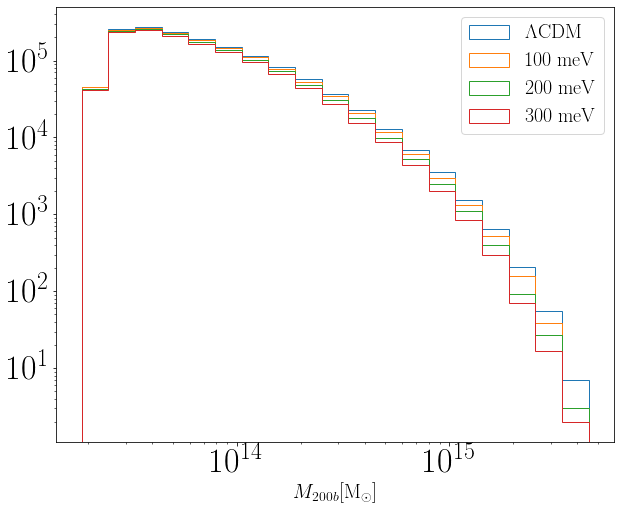

In [30]:
label_size = 34
mpl.rcParams['xtick.labelsize'] = label_size
mpl.rcParams['ytick.labelsize'] = label_size
fig = matplotlib.pyplot.gcf()
fig.set_size_inches(10, 12)
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 20}
matplotlib.rc('font', **font)
fig.set_size_inches(10, 8)

halo_mass = halo[:,20]
logbins = np.logspace(np.log10(min(halo_mass)), np.log10(max(halo_mass)), 20)
# Plot the histogram with logarithmic bins
plt.hist(halo_mass, bins=logbins, histtype='step',label=r"$\Lambda$CDM")

halo_mass100 = halo100[:,20]
plt.hist(halo_mass100, bins=logbins, histtype='step',label=r"100 meV")

halo_mass200 = halo200[:,20]
plt.hist(halo_mass200, bins=logbins, histtype='step',label=r"200 meV")

halo_mass300 = halo300[:,20]
plt.hist(halo_mass300, bins=logbins, histtype='step',label=r"300 meV")



plt.xlabel(r"$M_{200 b} [\mathrm{M}_\odot]$")
plt.xscale('log')
plt.yscale('log')
plt.legend()

## Number of halos:

In [32]:
halo_mass = halo[:,20]
print(np.shape(halo_mass)[0])

halo_mass100 = halo100[:,20]
print(np.shape(halo_mass100)[0])

halo_mass200 = halo200[:,20]
print(np.shape(halo_mass200)[0])

halo_mass300 = halo300[:,20]
print(np.shape(halo_mass300)[0])

# Plot the histogram with logarithmic bins
# plt.hist(halo_mass, bins=logbins, histtype='step',label=r"$\Lambda$CDM")

# halo_mass100 = halo100[:,20]
# plt.hist(halo_mass100, bins=logbins, histtype='step',label=r"100 meV")

# halo_mass200 = halo200[:,20]
# plt.hist(halo_mass200, bins=logbins, histtype='step',label=r"200 meV")

# halo_mass300 = halo300[:,20]

1498699
1443647
1366393
1293840


In [37]:
median = np.median(halo_mass)
print(f"Median: {median:.2e}")


Median: 5.44e+13


##  Mass limit

## Computing mass average of each catalogue

In [4]:
do_the_analysis = False

if do_the_analysis == True:
    boxsize = 1024
    obj = analysis.sim(boxsize)
    # sim_size = 'L_1200_N_512'
    # sims = ['lcdm','Mn0d3', 'Mn0d6']
    # for sim_size in sims_size:
    #     for sim in sims: 
    data_load = tools.nested_dict(5, list)

    # sim_size = 'L_512_N_256'
    sims = ['0.0ev','0.15ev', '0.3ev', '0.6ev']
    sim_size = 'L_1024_Ngrid_512'
    remove_subhalos = "no"
    snap_num = 2;

    for sim in sims:

        file_path = "/mn/stornext/u3/hassanif/neutrino_niayesh//simulations//"+sim_size+"/"+sim+"/output/"
        mass_limit = 1.35e13
        snapshot = file_path+'/snap00'+str(snap_num)+'_cdm'
        ptype = [1]
        cdm_pcl = obj.gadget_load(snapshot,ptype) # pos = arr[0], vel = arr[1];
        data_load[sim_size][sim]['pos'] = cdm_pcl[0]; 
        data_load[sim_size][sim]['vel'] = cdm_pcl[1];

        ######################
        ## halo read
        ######################
        if (remove_subhalos == "yes"):
            halo_address = file_path+'/halos/out_'+str(snap_num)+'_subhalo.txt'
        else:
            halo_address = file_path+'/halos/out_'+str(snap_num)+'.list' 

         #pop 1
        halo_p1 = obj.halo_selection(halo_address, '+', mass_limit, remove_subhalos, True);
        data_load[sim_size][sim]['halo_p1']['pos'] = halo_p1[:,:3]
        data_load[sim_size][sim]['halo_p1']['vel'] = halo_p1[:,3:6]
        data_load[sim_size][sim]['halo_p1']['M_avg'] ="{:.2e}".format(np.mean(halo_p1[:,7]))
        #pop 2
        halo_p2 = obj.halo_selection(halo_address, '-', mass_limit, remove_subhalos, True)
        data_load[sim_size][sim]['halo_p2']['pos'] = halo_p2[:,:3]
        data_load[sim_size][sim]['halo_p2']['vel'] = halo_p2[:,3:6]            
        data_load[sim_size][sim]['halo_p2']['M_avg'] = "{:.2e}".format(np.mean(halo_p2[:,7]))
        data_load[sim_size][sim]['Mass_resolution'] ="{:.2e}".format(np.min(halo_p2[:,7]))
        data_load[sim_size][sim]['Max_mass'] ="{:.2e}".format(np.max(halo_p1[:,7]))

        print("sim_size: ",sim_size,", sim: ",sim, ", snap_num: ",snap_num,", mass_limit: ", "{:.2e}".format(mass_limit),", p1 Mass:",data_load[sim_size][sim]['halo_p1']['M_avg'] , ", p2 Mass:", data_load[sim_size][sim]['halo_p2']['M_avg'])

        import numpy as np
        import MAS_library as MASL
        import Pk_library as PKL

        threads = 20
        boxsize = 1200.
        grid     = 128                     #grid size
        ptypes   = [1]                   #CDM + neutrinos
        MAS      = 'CIC'                   #Cloud-in-Cell
        do_RSD   = False                   #dont do redshif-space distortions
        axis     = 0                       #axis along which place RSD; not used here
        verbose  = True   #whether print information on the progress
        # Compute the effective number of particles/mass in each voxel
        delta = MASL.density_field_gadget(snapshot, ptypes, grid, MAS, do_RSD, axis, verbose)

        # compute density contrast: delta = rho/<rho> - 1
        delta /= np.mean(delta, dtype=np.float64);  delta -= 1.0


        #### delta for halos p1:
        delta_halos_p1 = np.zeros((grid,grid,grid), dtype=np.float32)
        print("array hosting density field is defined!","\n")
        posx = data_load[sim_size][sim]['halo_p1']['pos'][:,0];
        posy = data_load[sim_size][sim]['halo_p1']['pos'][:,1];
        posz = data_load[sim_size][sim]['halo_p1']['pos'][:,2];
        pos = np.zeros((np.shape(posx)[0],3))
        pos[:,0]=posx
        pos[:,1]=posy;
        pos[:,2]=posz #+ Vz/Hubble_conf_Mpc(3.0,H0, w ,Omega_kessence,Omega_rad,Omega_m)/c; # Redshift =3
        pos = pos.astype(np.float32)   #pos should be a numpy float array
        MASL.MA(pos,delta_halos_p1, boxsize,MAS)
        delta_halos_p1 /= np.mean(delta_halos_p1, dtype=np.float64);  delta_halos_p1 -= 1.0

        #### delta for halos p2:
        delta_halos_p2 = np.zeros((grid,grid,grid), dtype=np.float32)
        print("array hosting density field is defined!","\n")
        posx = data_load[sim_size][sim]['halo_p2']['pos'][:,0];
        posy = data_load[sim_size][sim]['halo_p2']['pos'][:,1]
        posz = data_load[sim_size][sim]['halo_p2']['pos'][:,2]
        pos = np.zeros((np.shape(posx)[0],3))
        pos[:,0]=posx
        pos[:,1]=posy;
        pos[:,2]=posz #+ Vz/Hubble_conf_Mpc(3.0,H0, w ,Omega_kessence,Omega_rad,Omega_m)/c; # Redshift =3
        pos = pos.astype(np.float32)   #pos should be a numpy float array
        MASL.MA(pos, delta_halos_p2, boxsize,MAS)
        delta_halos_p2 /= np.mean(delta_halos_p2, dtype=np.float64);  delta_halos_p2 -= 1.0

        MAS = ['CIC', 'CIC', 'CIC']
        Pk = PKL.XPk([delta, delta_halos_p1, delta_halos_p2], boxsize, axis, MAS, threads)
        # 3D P(k)
        k      = Pk.k3D
        Pk0_cdm  = Pk.Pk[:,0,0]  #monopole of field 1 (cdm)
        Pk0_p1  = Pk.Pk[:,0,1]  #monopole of field 2 (halo p1)
        Pk0_p2  = Pk.Pk[:,0,2]  #monopole of field 2 (cdm)

        Pk0_X_cdm_p1  = Pk.XPk[:,0,0] #monopole of 1-2 cross P(k) cross power better for computing bais!
        Pk0_X_cdm_p2 = Pk.XPk[:,0,1]
        # Pk0_X_p1_p2  = Pk.XPk[:,0,2] #monopole of 1-2 cross P(k) cross power better for computing bais!
        # Pk0_X_p1  = Pk.XPk[:,0,1] #monopole of 1-2 cross P(k) cross power better for computing bais!

        bias_cross_p1 = Pk0_X_cdm_p1/Pk0_cdm;
        bias_cross_p2 = Pk0_X_cdm_p2/Pk0_cdm;

        bias_p1_hh_mm = np.sqrt(Pk0_p1/Pk0_cdm)
        bias_p2_hh_mm = np.sqrt(Pk0_p2/Pk0_cdm)

        bias_lin_cross_p1 = np.mean(bias_cross_p1[10:20])
        bias_lin_cross_p2 = np.mean(bias_cross_p2[10:20])


        bias_lin_hh_mm_p1 = np.mean(bias_p1_hh_mm[10:20])
        bias_lin_hh_mm_p2 = np.mean(bias_p2_hh_mm[10:20])

        data_load[sim_size][sim]['k'] = k
        data_load[sim_size][sim]['Pk0_cdm'] = Pk0_cdm
        data_load[sim_size][sim]['Pk0_p1'] = Pk0_p1
        data_load[sim_size][sim]['Pk0_p2'] = Pk0_p2
        data_load[sim_size][sim]['Pk0_X_cdm_p1'] = Pk0_X_cdm_p1
        data_load[sim_size][sim]['Pk0_X_cdm_p2'] = Pk0_X_cdm_p2
        ## bias definitions
        data_load[sim_size][sim]['bias_cross_p1'] = bias_cross_p1
        data_load[sim_size][sim]['bias_cross_p2'] = bias_cross_p2
        data_load[sim_size][sim]['bias_p1_hh_mm'] = bias_p1_hh_mm
        data_load[sim_size][sim]['bias_p2_hh_mm'] = bias_p2_hh_mm
        ### linear bias
        data_load[sim_size][sim]['bias_lin_cross_p1'] = bias_lin_cross_p1
        data_load[sim_size][sim]['bias_lin_cross_p2'] = bias_lin_cross_p2
        data_load[sim_size][sim]['bias_lin_hh_mm_p1'] = bias_lin_hh_mm_p1
        data_load[sim_size][sim]['bias_lin_hh_mm_p2'] = bias_lin_hh_mm_p2
        

    ## Saving the data    
    # Loop over the simulation sizes
    saved_data = {}
    for sim_size in data_load.keys():
        # Initialize an empty dictionary for the simulation size
        saved_data[sim_size] = {}

        # Loop over the simulations
        for sim in sims:
            # Initialize an empty dictionary for the simulation
            saved_data[sim_size][sim] = {}

            # Save the data to the dictionary
            saved_data[sim_size][sim]['M_avg_p1'] = data_load[sim_size][sim]['halo_p1']['M_avg']
            saved_data[sim_size][sim]['M_avg_p2'] = data_load[sim_size][sim]['halo_p2']['M_avg'] 
            saved_data[sim_size][sim]['Mass_resolution'] = data_load[sim_size][sim]['Mass_resolution'] 
            saved_data[sim_size][sim]['Max_mass'] = data_load[sim_size][sim]['Max_mass'] 
            saved_data[sim_size][sim]['k'] = data_load[sim_size][sim]['k']
            saved_data[sim_size][sim]['Pk0_cdm'] = data_load[sim_size][sim]['Pk0_cdm']
            saved_data[sim_size][sim]['Pk0_p1'] = data_load[sim_size][sim]['Pk0_p1']
            saved_data[sim_size][sim]['Pk0_p2'] = data_load[sim_size][sim]['Pk0_p2']
            saved_data[sim_size][sim]['Pk0_X_cdm_p1'] = data_load[sim_size][sim]['Pk0_X_cdm_p1']
            saved_data[sim_size][sim]['Pk0_X_cdm_p2'] = data_load[sim_size][sim]['Pk0_X_cdm_p2']
            saved_data[sim_size][sim]['bias_cross_p1'] = data_load[sim_size][sim]['bias_cross_p1']
            saved_data[sim_size][sim]['bias_cross_p2'] = data_load[sim_size][sim]['bias_cross_p2']
            saved_data[sim_size][sim]['bias_p1_hh_mm'] = data_load[sim_size][sim]['bias_p1_hh_mm']
            saved_data[sim_size][sim]['bias_p2_hh_mm'] = data_load[sim_size][sim]['bias_p2_hh_mm']
            saved_data[sim_size][sim]['bias_lin_cross_p1'] = data_load[sim_size][sim]['bias_lin_cross_p1']
            saved_data[sim_size][sim]['bias_lin_cross_p2'] = data_load[sim_size][sim]['bias_lin_cross_p2']
            saved_data[sim_size][sim]['bias_lin_hh_mm_p1'] = data_load[sim_size][sim]['bias_lin_hh_mm_p1']
            saved_data[sim_size][sim]['bias_lin_hh_mm_p2'] = data_load[sim_size][sim]['bias_lin_hh_mm_p2']

    # Save the dictionary to a file
    with open('./output/spectra_bias_sims.pickle', 'wb') as f:
        pickle.dump(saved_data, f)
                    
                    
                    

## Loading the bias and halo info

In [5]:
with open('./output/spectra_bias_sims.pickle', 'rb') as f:
    data_load = pickle.load(f)

# Power spectra comparisons

<Figure size 720x864 with 0 Axes>

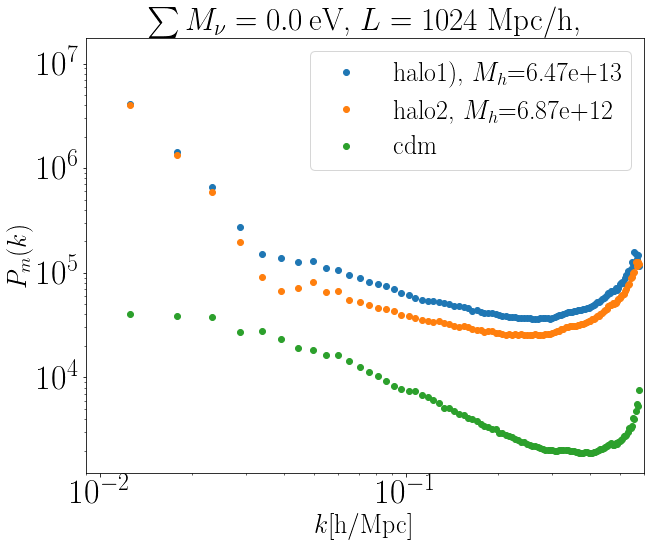

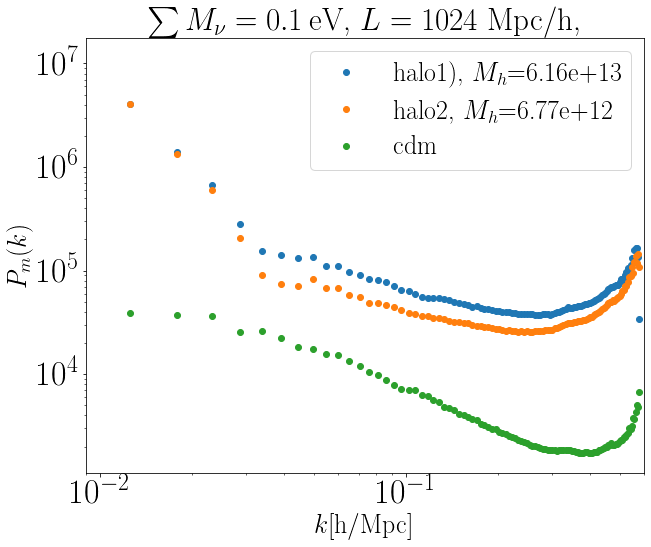

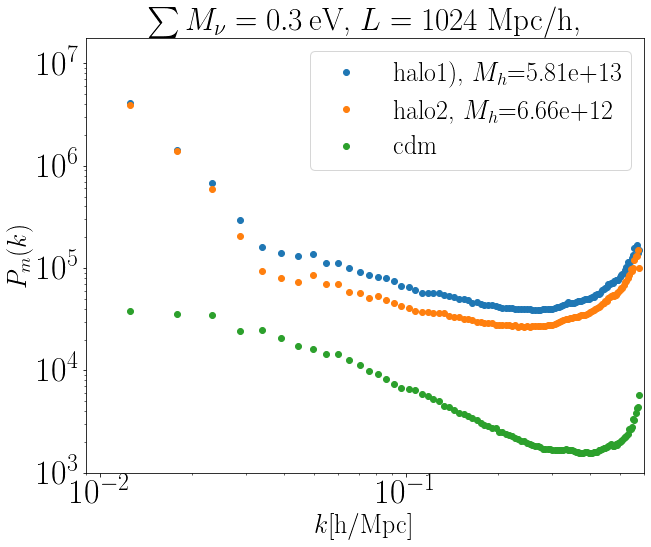

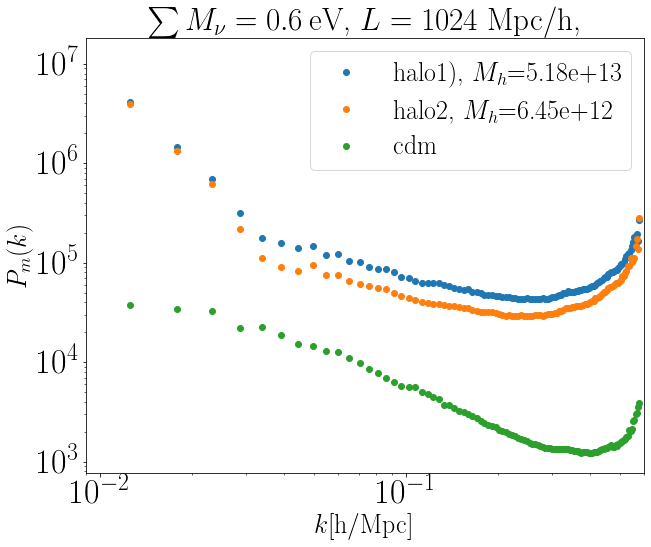

In [6]:
label_size = 34
mpl.rcParams['xtick.labelsize'] = label_size
mpl.rcParams['ytick.labelsize'] = label_size
fig = matplotlib.pyplot.gcf()
fig.set_size_inches(10, 12)
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 20}
matplotlib.rc('font', **font)




# # Pk is a python class containing the 1D, 2D and 3D power spectra, that can be retrieved as

sims = ['0.0ev','0.15ev', '0.3ev', '0.6ev']
sim_size = 'L_1024_Ngrid_512'
# # 3D P(k)
for sim in sims:
    plt.figure()
    label_size = 34
    mpl.rcParams['xtick.labelsize'] = label_size
    mpl.rcParams['ytick.labelsize'] = label_size
    fig = matplotlib.pyplot.gcf()
    fig.set_size_inches(10, 8)
    plt.rc('text', usetex=True)
    font = {'family' : 'normal',
            'weight' : 'bold',
            'size'   : text_size}
    matplotlib.rc('font', **font)
    k = data_load[sim_size][sim]['k']
    Pk0_cdm = data_load[sim_size][sim]['Pk0_cdm']
    Pk0_p1 = data_load[sim_size][sim]['Pk0_p1']
    Pk0_p2 = data_load[sim_size][sim]['Pk0_p2']

    plt.loglog(k, Pk0_p1,"o", label = "halo1), $M_h$="+str(data_load[sim_size][sim]['M_avg_p1']))
    plt.loglog(k, Pk0_p2,"o", label = "halo2, $M_h$="+str(data_load[sim_size][sim]['M_avg_p2']))
    plt.loglog(k, Pk0_cdm,"o", label = "cdm")

    # plt.loglog(k, Pk0_X_cdm_p1,"o", label = "cdm x halo(p1)")
    # plt.loglog(k, Pk0_X_cdm_p2,"o", label = "cdm x halo(p2)")
    # plt.loglog(k, Pk0_X_p1_p2,"o", label = "halo(p1) x halo(p2)")

    # plt.ylim(1.e3,2.e4)
    plt.xlim(9.e-3,0.6)

    plt.title(format_mass_string(sim)+", "+ parse_name(sim_size))
    
    plt.ylabel(r'${P}_m(k)$')
    plt.xlabel(r'$k[\rm{ h/Mpc}]$')
    plt.legend()

## Relative difference

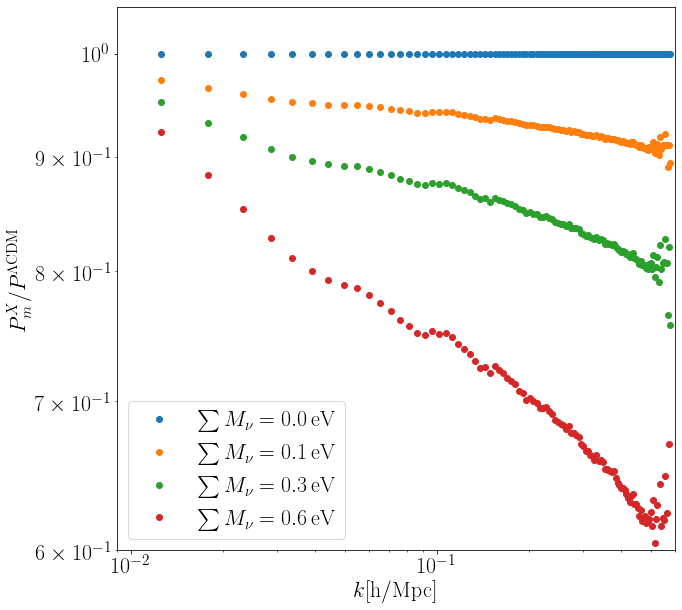

In [7]:
label_size = 22
mpl.rcParams['xtick.labelsize'] = label_size
mpl.rcParams['ytick.labelsize'] = label_size
fig = matplotlib.pyplot.gcf()
fig.set_size_inches(10, 10)
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 22}
matplotlib.rc('font', **font)




# # Pk is a python class containing the 1D, 2D and 3D power spectra, that can be retrieved as

sims = ['0.0ev','0.15ev', '0.3ev', '0.6ev']
sim_size = 'L_1024_Ngrid_512'
# # 3D P(k)
for sim_base in ['0.0ev']:
    for sim in sims:

        k = data_load[sim_size][sim]['k']
        Pk0_cdm = data_load[sim_size][sim]['Pk0_cdm']
        pk2_intrp = interp1d(k,Pk0_cdm, fill_value='extrapolate')
        
        k = data_load[sim_size][sim_base]['k']
        Pk0_cdm = data_load[sim_size][sim_base]['Pk0_cdm']
        pk1_intrp = interp1d(k,Pk0_cdm, fill_value='extrapolate')
    
        plt.loglog(k, pk2_intrp(k)/pk1_intrp(k),"o", label =format_mass_string(sim))

        # plt.loglog(k, Pk0_X_cdm_p1,"o", label = "cdm x halo(p1)")
        # plt.loglog(k, Pk0_X_cdm_p2,"o", label = "cdm x halo(p2)")
        # plt.loglog(k, Pk0_X_p1_p2,"o", label = "halo(p1) x halo(p2)")

        plt.ylim(0.6,1.05)
        plt.xlim(9.e-3,0.6)

        # plt.title(format_mass_string(sim)+", "+ parse_name(sim_size))

        plt.ylabel(r'${P}_m^{X}/P^{\Lambda {\rm CDM}}$')
        plt.xlabel(r'$k[\rm{ h/Mpc}]$')
        plt.legend()

### Computing the spectra and the cross spectra

## biases

<Figure size 720x864 with 0 Axes>

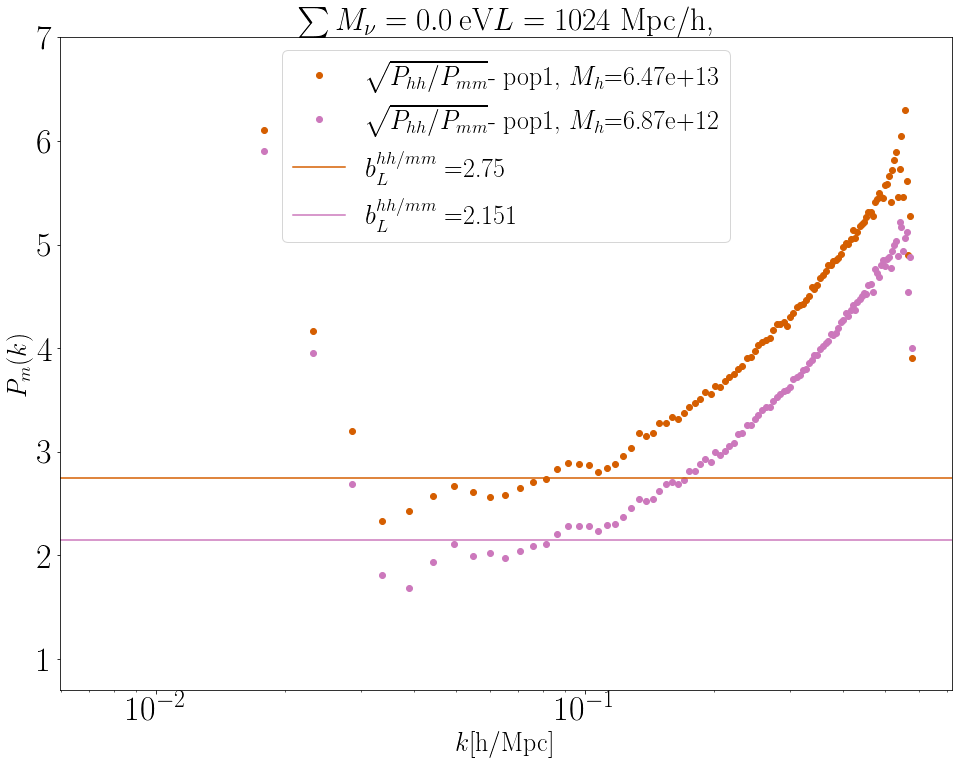

In [12]:
label_size = 34
mpl.rcParams['xtick.labelsize'] = label_size
mpl.rcParams['ytick.labelsize'] = label_size
fig = matplotlib.pyplot.gcf()
fig.set_size_inches(10, 12)
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : text_size}
matplotlib.rc('font', **font)




# # Pk is a python class containing the 1D, 2D and 3D power spectra, that can be retrieved as

sims = ['0.0ev','0.15ev', '0.3ev', '0.6ev']
sim_size = 'L_1024_Ngrid_512'
# # 3D P(k)
for sim in sims[:1]:
    plt.figure()
    label_size = 34
    mpl.rcParams['xtick.labelsize'] = label_size
    mpl.rcParams['ytick.labelsize'] = label_size
    fig = matplotlib.pyplot.gcf()
    fig.set_size_inches(16, 12)
    plt.rc('text', usetex=True)
    font = {'family' : 'normal',
            'weight' : 'bold',
            'size'   : text_size}
    matplotlib.rc('font', **font)
    ######
    k = data_load[sim_size][sim]['k']
    bias_cross_p1 = data_load[sim_size][sim]['bias_cross_p1'] 
    bias_cross_p2 = data_load[sim_size][sim]['bias_cross_p2']
    bias_p1_hh_mm = data_load[sim_size][sim]['bias_p1_hh_mm']
    bias_p2_hh_mm = data_load[sim_size][sim]['bias_p2_hh_mm']

    bias_lin_cross_p1 = data_load[sim_size][sim]['bias_lin_cross_p1']
    bias_lin_cross_p2 = data_load[sim_size][sim]['bias_lin_cross_p2']
    bias_lin_hh_mm_p1 = data_load[sim_size][sim]['bias_lin_hh_mm_p1']
    bias_lin_hh_mm_p2 = data_load[sim_size][sim]['bias_lin_hh_mm_p2']


    
    # plt.semilogx(k, bias_cross_p1,"o",color=Colors[0], label = r"$P_{ h \times m}/P_{mm}$- pop1, $M_h$="+str(data_load[sim_size][sim]['M_avg_p1']))
    # plt.semilogx(k, bias_cross_p2,"o",color=Colors[1], label = r"$P_{ h \times m}/P_{mm}$- pop1, $M_h$="+str(data_load[sim_size][sim]['M_avg_p2']))
    # plt.axhline(y=bias_lin_cross_p1, color=Colors[0], linestyle='-',label = "$b_L^{X}$ ="+str(round(bias_lin_cross_p1,3)))
    # plt.axhline(y=bias_lin_cross_p2, color=Colors[1], linestyle='-',label = "$b_L^{X}$ ="+str(round(bias_lin_cross_p2,3)))    
    
    plt.semilogx(k, bias_p1_hh_mm,"o",color=Colors[3], label = r"$\sqrt{P_{ hh}/P_{mm}}$- pop1, $M_h$="+str(data_load[sim_size][sim]['M_avg_p1']))
    plt.semilogx(k, bias_p2_hh_mm,"o",color=Colors[4], label = r"$\sqrt{P_{ hh}/P_{mm}}$- pop1, $M_h$="+str(data_load[sim_size][sim]['M_avg_p2']))

    plt.axhline(y=bias_lin_hh_mm_p1, color=Colors[3], linestyle='-',label = "$b_L^{hh/mm}$ ="+str(round(bias_lin_hh_mm_p1,3)))
    plt.axhline(y=bias_lin_hh_mm_p2, color=Colors[4], linestyle='-',label = "$b_L^{hh/mm}$ ="+str(round(bias_lin_hh_mm_p2,3)))    
    
    # plt.loglog(k, Pk0_X_cdm_p1,"o", label = "cdm x halo(p1)")
    # plt.loglog(k, Pk0_X_cdm_p2,"o", label = "cdm x halo(p2)")
    # plt.loglog(k, Pk0_X_p1_p2,"o", label = "halo(p1) x halo(p2)")

    plt.ylim(0.7,7)
    plt.title(format_mass_string(sim)+ parse_name(sim_size))
    
    plt.ylabel(r'${P}_m(k)$')
    plt.xlabel(r'$k[\rm{ h/Mpc}]$')
    plt.legend()

## Bias definition

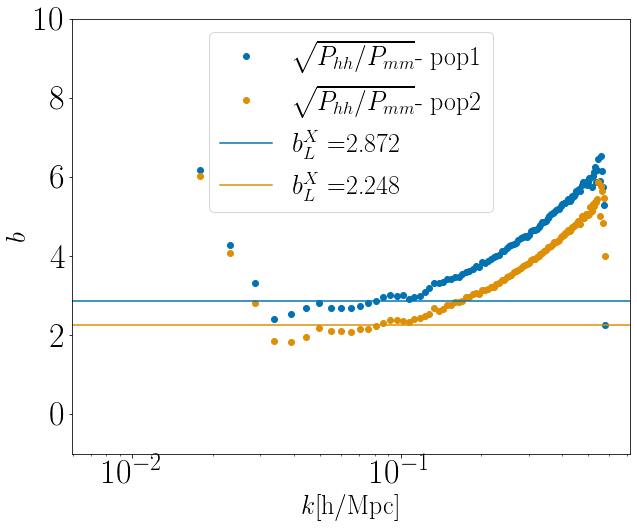

In [13]:
%matplotlib inline
import matplotlib as mpl
label_size = 34
mpl.rcParams['xtick.labelsize'] = label_size
mpl.rcParams['ytick.labelsize'] = label_size
fig = matplotlib.pyplot.gcf()
fig.set_size_inches(10, 8)
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : text_size}
matplotlib.rc('font', **font)

sim  = '0.15ev'
# # Pk is a python class containing the 1D, 2D and 3D power spectra, that can be retrieved as
bias_cross_p1 = data_load[sim_size][sim]['bias_cross_p1']
bias_cross_p2 = data_load[sim_size][sim]['bias_cross_p2']

bias_p1_hh_mm = data_load[sim_size][sim]['bias_p1_hh_mm']
bias_p2_hh_mm = data_load[sim_size][sim]['bias_p2_hh_mm']

bias_lin_cross_p1 = data_load[sim_size][sim]['bias_lin_cross_p1']
bias_lin_cross_p2 = data_load[sim_size][sim]['bias_lin_cross_p2']


bias_lin_hh_mm_p1 = data_load[sim_size][sim]['bias_lin_hh_mm_p1']
bias_lin_hh_mm_p2 =data_load[sim_size][sim]['bias_lin_hh_mm_p2']


# # 3D P(k)
plt.semilogx(k, bias_p1_hh_mm,"o",color=Colors[0], label = r"$\sqrt{P_{ hh}/P_{mm}}$- pop1")
plt.semilogx(k, bias_p2_hh_mm,"o",color=Colors[1], label = r"$\sqrt{P_{ hh}/P_{mm}}$- pop2")
plt.axhline(y=bias_lin_hh_mm_p1, color=Colors[0], linestyle='-',label = "$b_L^{X}$ ="+str(round(bias_lin_hh_mm_p1,3)))
plt.axhline(y=bias_lin_hh_mm_p2, color=Colors[1], linestyle='-',label = "$b_L^{X}$ ="+str(round(bias_lin_hh_mm_p2,3)))


# plt.semilogx(k, bias_hh_mm,"o",  label = r"$\sqrt{P_{ hh}/P_{mm}}$")
# plt.axhline(y=bias_lin_cross, color=Colors[3], linestyle='-',label = "$b_L^{X}$")
# plt.axhline(y=bias_lin_hh_mm, color=Colors[2], linestyle='-',label = "$b_L^{hh/mm}$")


plt.ylim(-1,10)
plt.ylabel(r'$b$')
plt.xlabel(r'$k[\rm{ h/Mpc}]$')
plt.legend()

# Plot

# Computing $\Delta_{c\nu}$ and $\Delta x$ for each halo population and each simulation

### Formula Computing $\Delta v_{\nu c}$ from Eq. 30 of arXiv:1611.04589v2

In [14]:
def Delta_v_nuc (b_h, M_h, m_nu, v_nuc_16, degeneracy=3):
    return degeneracy * 0.2 * (b_h + (M_h/(1.3*1.e14))**(0.85)) * (m_nu/0.1)**(2.9) * (v_nuc_16/193.0) # km/s
def Delta_x (b_h, M_h, m_nu, v_nuc_16, degeneracy=3):
    return degeneracy * 1.5 * (b_h + (M_h/(1.3*1.e14))**(0.85)) * (m_nu/0.1)**(2.9) * (v_nuc_16/193.0)# kpc

In [15]:
con1 = (data_all[sims_all[1]]['cdm']['dx'] >15.9) & (data_all[sims_all[1]]['cdm']['dx'] >16.0)
con2 = (data_all[sims_all[1]]['cdm']['number_samples'] ==500) 
m_nu=0.15/3.
v_nuc_16 = np.sqrt(data_all[sims_all[1]]['cdm']['<vb.vb>'][con1 & con2])
v_nuc_16 = v_nuc_16.iloc[0]

In [16]:
v_nuc_16

382.93041551305373

In [17]:
data_new = tools.nested_dict(5, list)

mass_limit = 1.35e13;
sims = ['0.0ev','0.15ev', '0.3ev', '0.6ev']
sim_size = 'L_1024_Ngrid_512'
for sim in sims:
    if sim == "0.0ev":
        m_nu=0
        v_nuc_16=0
    elif sim == "0.15ev":
        con1 = (data_all[sims_all[1]]['cdm']['dx'] ==16.0)
        con2 = (data_all[sims_all[1]]['cdm']['number_samples'] ==500) 
        m_nu=0.15/3.
        v_nuc_16 = np.sqrt(data_all[sims_all[1]]['cdm']['<vb.vb>'][con1 & con2])
        v_nuc_16 = v_nuc_16.iloc[0]

    elif sim == "0.3ev":
        con1 = (data_all[sims_all[2]]['cdm']['dx'] ==16.0)
        con2 = (data_all[sims_all[2]]['cdm']['number_samples'] ==500) 
        m_nu=0.3/3.
        v_nuc_16 = np.sqrt(data_all[sims_all[2]]['cdm']['<vb.vb>'][con1 & con2])
        v_nuc_16 = v_nuc_16.iloc[0]
            
    elif sim == "0.6ev":
        con1 = (data_all[sims_all[3]]['cdm']['dx'] ==16.0)
        con2 = (data_all[sims_all[3]]['cdm']['number_samples'] ==500) 
        m_nu=0.6/3.
        v_nuc_16 = np.sqrt(data_all[sims_all[3]]['cdm']['<vb.vb>'][con1 & con2])
        v_nuc_16 = v_nuc_16.iloc[0]
        

    # bias_lin_cross_p1 = data_load[sim_size][sim]['bias_lin_cross_p1']
    # bias_lin_cross_p2 = data_load[sim_size][sim]['bias_lin_cross_p2']
    bias_lin_hh_mm_p1 = data_load[sim_size][sim]['bias_lin_hh_mm_p1']
    bias_lin_hh_mm_p2 = data_load[sim_size][sim]['bias_lin_hh_mm_p2']
    M_h_p1 = data_load[sim_size][sim]['M_avg_p1'];
    M_h_p2 = data_load[sim_size][sim]['M_avg_p2'];
    
    # data_load[sim_size][sim]['Delta_v_nu_c']['p1']['b_cross'] = Delta_v_nuc(bias_lin_cross_p1, np.double(M_h_p1), m_nu, v_nuc_16)
    # data_load[sim_size][sim]['Delta_v_nu_c']['p2']['b_cross'] = Delta_v_nuc(bias_lin_cross_p2, np.double(M_h_p2), m_nu, v_nuc_16)
    # print(Delta_v_nuc(bias_lin_hh_mm_p1, np.double(M_h_p1), m_nu, v_nuc_16))
    data_new[sim_size][sim]['Delta_v_nu_c']['p1']['b_hh'] = Delta_v_nuc(bias_lin_hh_mm_p1, np.double(M_h_p1), m_nu, v_nuc_16)
    data_new[sim_size][sim]['Delta_v_nu_c']['p2']['b_hh'] = Delta_v_nuc(bias_lin_hh_mm_p2, np.double(M_h_p2), m_nu, v_nuc_16)

    data_new[sim_size][sim]['dx']['p1']['b_hh'] = Delta_x(bias_lin_cross_p1, np.double(M_h_p1), m_nu, v_nuc_16)
    data_new[sim_size][sim]['dx']['p2']['b_hh'] = Delta_x(bias_lin_cross_p2, np.double(M_h_p2), m_nu, v_nuc_16)
    
    
    data_new[sim_size][sim]['alpha'] = (Delta_v_nuc(bias_lin_hh_mm_p1, np.double(M_h_p1), m_nu, v_nuc_16) -  Delta_v_nuc(bias_lin_hh_mm_p2, np.double(M_h_p2), m_nu, v_nuc_16))/v_nuc_16
    
    print("sim_size: ",sim_size,", sim: ",sim, ", mass_limit: ", "{:.2e}".format(mass_limit),", p1 Mass:",data_load[sim_size][sim]['M_avg_p1'] , ", p2 Mass:", data_load[sim_size][sim]['M_avg_p2'])
    print(r"$b(p1)$ = ",bias_lin_hh_mm_p1, r"$b(p2)$ = ",bias_lin_hh_mm_p2, ", m_nu=",m_nu)

    print(r"$\Delta x(p1)$ [kpc] = ",data_new[sim_size][sim]['dx']['p1']['b_cross'])
    print(r"$\Delta x(p2)$ [kpc] = ",data_new[sim_size][sim]['dx']['p2']['b_cross'])
    
    # print(r"$\Delta v_{c\nu}(p1)$ [km/s] = ",data_new[sim_size][sim]['Delta_v_nu_c']['p1']['b_cross'])
    # print(r"$\Delta v_{c\nu}(p2)$ [km/s] = ",data_new[sim_size][sim]['Delta_v_nu_c']['p2']['b_cross'])
    
    print(r"$\Delta v_{c\nu}(p1, b2)$ [km/s] = ",data_new[sim_size][sim]['Delta_v_nu_c']['p1']['b_hh'])
    print(r"$\Delta v_{c\nu}(p2, b2)$ [km/s] = ",data_new[sim_size][sim]['Delta_v_nu_c']['p2']['b_hh'])
    print(r"$v_b$",v_nuc_16)

    print(r"$(\Delta v_{c\nu}(p1, b2)$ [km/s] - $\Delta v_{c\nu}(p1, b2)$ [km/s])/$v_b$(16 Mpc/h)", data_new[sim_size][sim]['alpha'])
    
    print("\n \n")



sim_size:  L_1024_Ngrid_512 , sim:  0.0ev , mass_limit:  1.35e+13 , p1 Mass: 6.47e+13 , p2 Mass: 6.87e+12
$b(p1)$ =  2.7498114619699665 $b(p2)$ =  2.1512736242554618 , m_nu= 0
$\Delta x(p1)$ [kpc] =  []
$\Delta x(p2)$ [kpc] =  []
$\Delta v_{c\nu}(p1, b2)$ [km/s] =  0.0
$\Delta v_{c\nu}(p2, b2)$ [km/s] =  0.0
$v_b$ 0
$(\Delta v_{c\nu}(p1, b2)$ [km/s] - $\Delta v_{c\nu}(p1, b2)$ [km/s])/$v_b$(16 Mpc/h) nan

 

sim_size:  L_1024_Ngrid_512 , sim:  0.15ev , mass_limit:  1.35e+13 , p1 Mass: 6.16e+13 , p2 Mass: 6.77e+12
$b(p1)$ =  2.871519973463721 $b(p2)$ =  2.2475623081464216 , m_nu= 0.049999999999999996
$\Delta x(p1)$ [kpc] =  []
$\Delta x(p2)$ [kpc] =  []
$\Delta v_{c\nu}(p1, b2)$ [km/s] =  0.5292832432814558
$\Delta v_{c\nu}(p2, b2)$ [km/s] =  0.36234611103165265
$v_b$ 373.5989870502863
$(\Delta v_{c\nu}(p1, b2)$ [km/s] - $\Delta v_{c\nu}(p1, b2)$ [km/s])/$v_b$(16 Mpc/h) 0.00044683507727855126

 

sim_size:  L_1024_Ngrid_512 , sim:  0.3ev , mass_limit:  1.35e+13 , p1 Mass: 5.81e+13 , p2 

<ipython-input-17-d4169f2a9950>:49: RuntimeWarning: invalid value encountered in double_scalars
  data_new[sim_size][sim]['alpha'] = (Delta_v_nuc(bias_lin_hh_mm_p1, np.double(M_h_p1), m_nu, v_nuc_16) -  Delta_v_nuc(bias_lin_hh_mm_p2, np.double(M_h_p2), m_nu, v_nuc_16))/v_nuc_16


In [41]:
 data_all[name_base]['halo']

,simulation,sim_info,snapshot_num,ngrid,dx,number_samples,alpha_p1,alpha_p2,std_alpha_p1,std_alpha_p2,num_subbox_analysed,<vb.vb>,<vb.vp1>,<vb.vp2>,v_bulk_kind
0,0.0ev,L_1024_N_512,2,17,60.235294,5,0.919509,0.889940,0.000000e+00,0.000000,1,110205.179688,101334.693030,98075.970198,halo
1,0.0ev,L_1024_N_512,2,21,48.761905,50,1.093604,1.017790,2.247376e+09,35572.837207,30,90734.070312,99227.171010,92348.256201,halo
2,0.0ev,L_1024_N_512,2,49,20.897959,250,0.991353,1.108791,1.187338e+10,154375.654115,59,157468.671875,156106.984394,174599.858012,halo
3,0.0ev,L_1024_N_512,2,47,21.787234,50,0.931664,1.198544,2.373290e+10,208087.171120,13,180987.250000,168619.312531,216921.139559,halo
4,0.0ev,L_1024_N_512,2,47,21.787234,100,1.100197,1.039381,2.410733e+10,238750.186061,24,193265.859375,212630.546364,200876.833904,halo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
513,0.0ev,L_1024_N_512,2,21,48.761905,250,1.054378,1.022533,3.870734e+09,70734.035456,166,97360.210938,102654.503241,99554.068617,halo
514,0.0ev,L_1024_N_512,2,65,15.753846,50,0.969355,0.906106,1.592655e+10,53831.064190,8,162740.156250,157752.936501,147459.765195,halo
515,0.0ev,L_1024_N_512,2,42,24.380952,1000,1.087685,1.126892,1.859123e+10,126424.017390,380,153581.781250,167048.652450,173070.024362,halo
516,0.0ev,L_1024_N_512,2,56,18.285714,50,1.217985,1.426784,6.367136e+10,323180.615077,12,173516.984375,211341.095191,247571.193077,halo


# $\alpha$

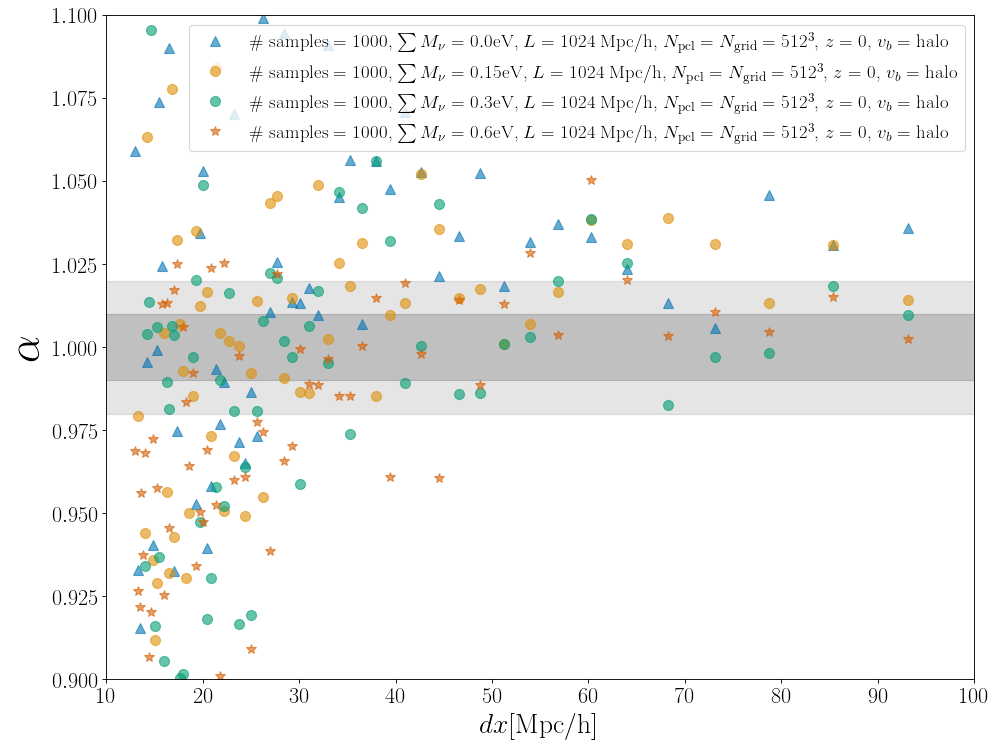

In [56]:
set_points2 = ["^","o","o","*","s","o","*"]


#########
c=14
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
#########

l=0
str_p1 = r", ($M \ge M_{\rm th}$, $v_b^{(\rm cdm)}$)"
str_p2 = r", ($M \le M_{\rm th}$, $v_b^{(\rm cdm)}$)"

x_val = np.arange(0,500,1)
figure(figsize=(14, 11), dpi=80)
for name in [sims_all[0], sims_all[1], sims_all[2], sims_all[3]]:
    for number_samples in [1000]:
    # 
    #############  
    ### conditions: set on the number of samples choses
    #############  
        data_alpha = data_all[name]['halo']
        con1 = (data_alpha['number_samples'] == number_samples) #(data_alpha['number_samples'] == number_samples)
        x_p1 = data_alpha[con1]['dx']
        alpha_p1 = data_alpha[con1]['alpha_p1']
        std_alpha_p1 = data_alpha[con1]['std_alpha_p1']
        alpha_p2 = data_alpha[con1]['alpha_p2']

        # data_alpha = data_all[name]['cdm']
        # con1 = (data_alpha['number_samples'] == number_samples)
        # x_p1 = data_alpha[con1]['dx']
        # alpha_p2 = data_alpha[con1]['alpha_p1']
        # std_alpha_p1 = data_alpha[con1]['std_alpha_p1']
        
        plt.plot(x_p1, alpha_p1/alpha_p2, set_points2[l],color=Colors[l], markersize=9, alpha=0.6, label="\# samples = "+str(number_samples)+", "+parse_name(name)+", $v_b=$ halo")#+str_p1)
        x_p2 = data_alpha[con1]['dx']
        alpha_p2 = data_alpha[con1]['alpha_p2']
        # plt.plot(x_p2, alpha_p2, set_points2[l], color=Colors[l+4], markersize= 10, alpha=0.7, label=parse_name(name)+str_p2)
        plt.fill_between(x_val, (1-0.02), (1+0.02), color="gray", alpha=0.05)
        plt.fill_between(x_val, (1-0.01), (1+0.01), color="gray", alpha=0.1)

        # plt.title(" \# sub-boxes: "+ str(number_samples), fontsize=20)
        plt.rcParams['xtick.labelsize']=20
        plt.rcParams['ytick.labelsize']=20
        plt.xlabel("$dx$[Mpc/h]",fontsize=25)
        plt.ylabel(r"$\alpha$",fontsize=40)
        plt.legend(fontsize=17)
        plt.xlim(10,100)
        plt.ylim(1-0.1,1+0.1)
        l=l+1


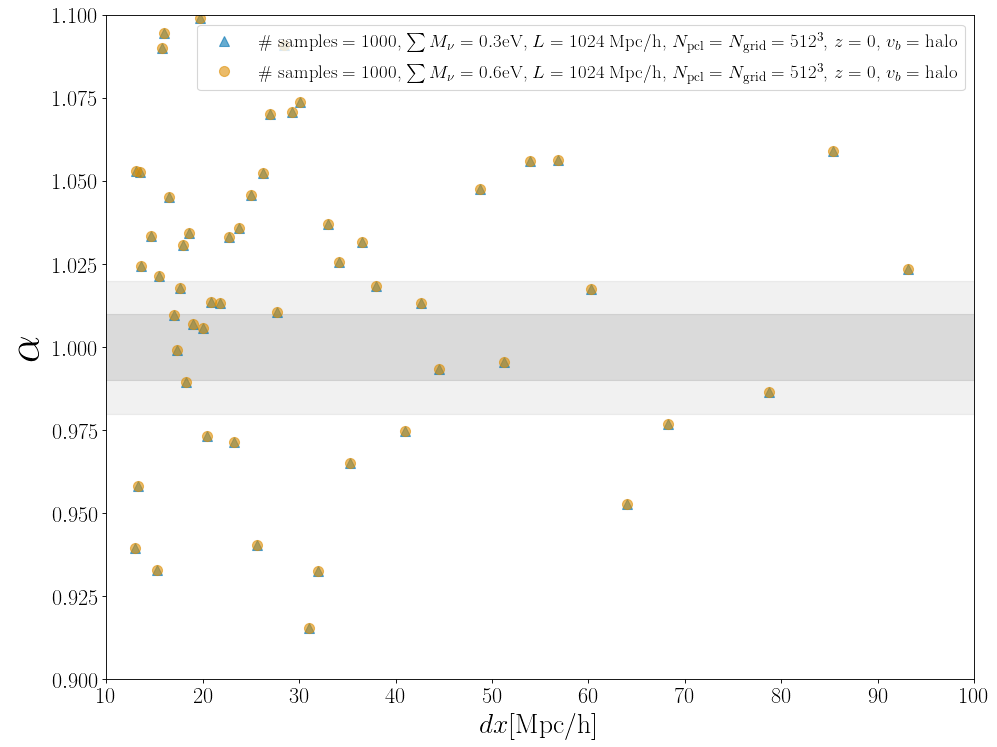

In [52]:
set_points2 = ["^","o","o","*","s","o","*"]


#########
c=14
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
#########

l=0
str_p1 = r", ($M \ge M_{\rm th}$, $v_b^{(\rm cdm)}$)"
str_p2 = r", ($M \le M_{\rm th}$, $v_b^{(\rm cdm)}$)"

x_val = np.arange(0,500,1)
figure(figsize=(14, 11), dpi=80)
for name_base in [sims_all[0]]:
    for name in [sims_all[2], sims_all[3]]:
        for number_samples in [1000]:
        # 
        #############  
        ### conditions: set on the number of samples choses
        #############  
            data_alpha = data_all[name]['halo']
            con1 = (data_alpha['number_samples'] == number_samples) #(data_alpha['number_samples'] == number_samples)
            x_p1 = data_alpha[con1]['dx']
            alpha_p1 = data_alpha[con1]['alpha_p1']
            # std_alpha_p1 = data_alpha[con1]['std_alpha_p1']
            alpha_p2 = data_alpha[con1]['alpha_p2']

            data_alpha_base = data_all[name_base]['halo']
            con1_base = (data_alpha_base['number_samples'] == number_samples) #(data_alpha['number_samples'] == number_samples)
            # x_p1 = data_alpha_base[con1]['dx']
            alpha_p1_base = data_alpha_base[con1_base]['alpha_p1']
            # std_alpha_p1 = data_alpha_base[con1]['std_alpha_p1']
            alpha_p2_base = data_alpha_base[con1_base]['alpha_p2']
            
            # data_alpha = data_all[name]['cdm']
            # con1 = (data_alpha['number_samples'] == number_samples)
            # x_p1 = data_alpha[con1]['dx']
            # alpha_p2 = data_alpha[con1]['alpha_p1']
            # std_alpha_p1 = data_alpha[con1]['std_alpha_p1']
            ratio_base = alpha_p1_base/alpha_p2_base;
            ratio = alpha_p1/alpha_p2;
            # print(np.shape(x_p1, ratio))
            # print(ratio/ratio_base)
            plt.plot(x_p1, ratio_base, set_points2[l],color=Colors[l], markersize=9, alpha=0.6, label="\# samples = "+str(number_samples)+", "+parse_name(name)+", $v_b=$ halo")#+str_p1)
            # x_p2 = data_alpha[con1]['dx']
            # alpha_p2 = data_alpha[con1]['alpha_p2']
            # plt.plot(x_p2, alpha_p2, set_points2[l], color=Colors[l+4], markersize= 10, alpha=0.7, label=parse_name(name)+str_p2)
            plt.fill_between(x_val, (1-0.02), (1+0.02), color="gray", alpha=0.05)
            plt.fill_between(x_val, (1-0.01), (1+0.01), color="gray", alpha=0.1)

            # plt.title(" \# sub-boxes: "+ str(number_samples), fontsize=20)
            plt.rcParams['xtick.labelsize']=20
            plt.rcParams['ytick.labelsize']=20
            plt.xlabel("$dx$[Mpc/h]",fontsize=25)
            plt.ylabel(r"$\alpha$",fontsize=40)
            plt.legend(fontsize=17)
            plt.xlim(10,100)
            plt.ylim(1-0.1,1+0.1)
            l=l+1


In [55]:
ratio

3      0.906694
4      0.988862
13     1.123842
15     0.998111
23     0.952443
         ...   
472    1.013475
477    0.950518
484    1.022777
491    0.898352
509    0.985282
Length: 70, dtype: float64

In [28]:
# np.shape(x_p1)
ratio_base = alpha_p1_base/alpha_p2_base;
ratio = alpha_p1/alpha_p2

In [31]:
ratio_base.shape

(72,)

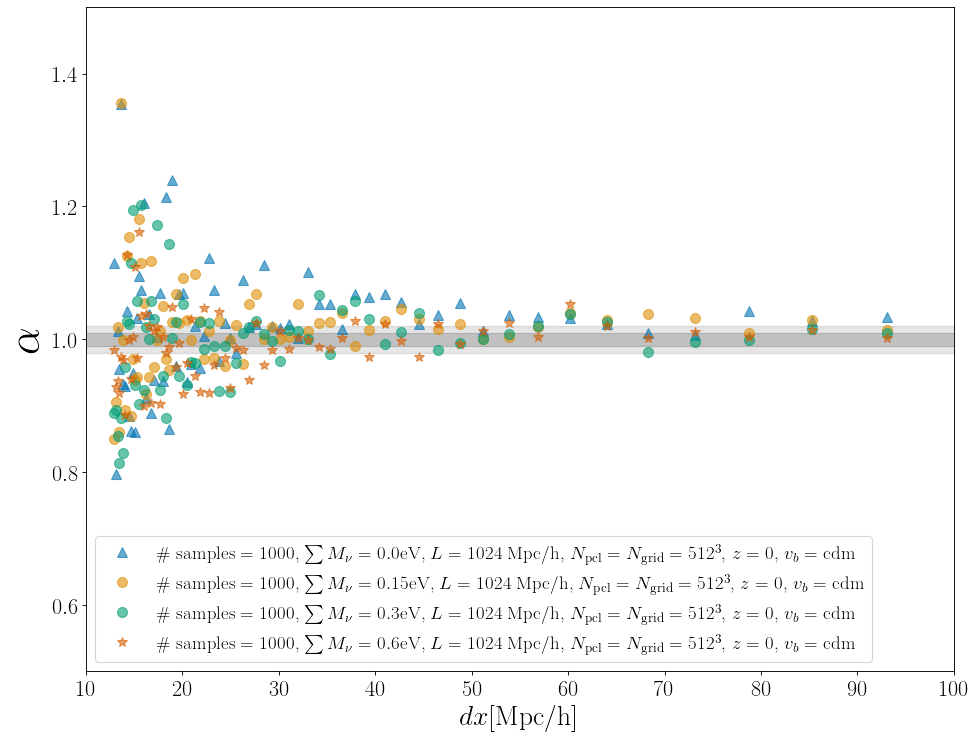

In [51]:
set_points2 = ["^","o","o","*","s","o","*"]


#########
c=14
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
#########

l=0
str_p1 = r", ($M \ge M_{\rm th}$, $v_b^{(\rm cdm)}$)"
str_p2 = r", ($M \le M_{\rm th}$, $v_b^{(\rm cdm)}$)"

x_val = np.arange(0,500,1)
figure(figsize=(14, 11), dpi=80)
for name in [sims_all[0], sims_all[1], sims_all[2], sims_all[3]]:
    for number_samples in [1000]:
    # 
    #############  
    ### conditions: set on the number of samples choses
    #############  
        data_alpha = data_all[name]['cdm']
        con1 = (data_alpha['number_samples'] == number_samples) #(data_alpha['number_samples'] == number_samples)
        x_p1 = data_alpha[con1]['dx']
        alpha_p1 = data_alpha[con1]['alpha_p1']
        std_alpha_p1 = data_alpha[con1]['std_alpha_p1']
        alpha_p2 = data_alpha[con1]['alpha_p2']

        # data_alpha = data_all[name]['cdm']
        # con1 = (data_alpha['number_samples'] == number_samples)
        # x_p1 = data_alpha[con1]['dx']
        # alpha_p2 = data_alpha[con1]['alpha_p1']
        # std_alpha_p1 = data_alpha[con1]['std_alpha_p1']
        
        plt.plot(x_p1, alpha_p1/alpha_p2, set_points2[l],color=Colors[l], markersize=9, alpha=0.6, label="\# samples = "+str(number_samples)+", "+parse_name(name)+", $v_b=$ cdm")#+str_p1)
        x_p2 = data_alpha[con1]['dx']
        alpha_p2 = data_alpha[con1]['alpha_p2']
        # plt.plot(x_p2, alpha_p2, set_points2[l], color=Colors[l+4], markersize= 10, alpha=0.7, label=parse_name(name)+str_p2)
        plt.fill_between(x_val, (1-0.02), (1+0.02), color="gray", alpha=0.05)
        plt.fill_between(x_val, (1-0.01), (1+0.01), color="gray", alpha=0.1)

        # plt.title(" \# sub-boxes: "+ str(number_samples), fontsize=20)
        plt.rcParams['xtick.labelsize']=20
        plt.rcParams['ytick.labelsize']=20
        plt.xlabel("$dx$[Mpc/h]",fontsize=25)
        plt.ylabel(r"$\alpha$",fontsize=40)
        plt.legend(fontsize=17)
        plt.xlim(10,100)
        plt.ylim(1-0.5,1+0.5)
        l=l+1


# The ratios

## $\alpha$ Figure

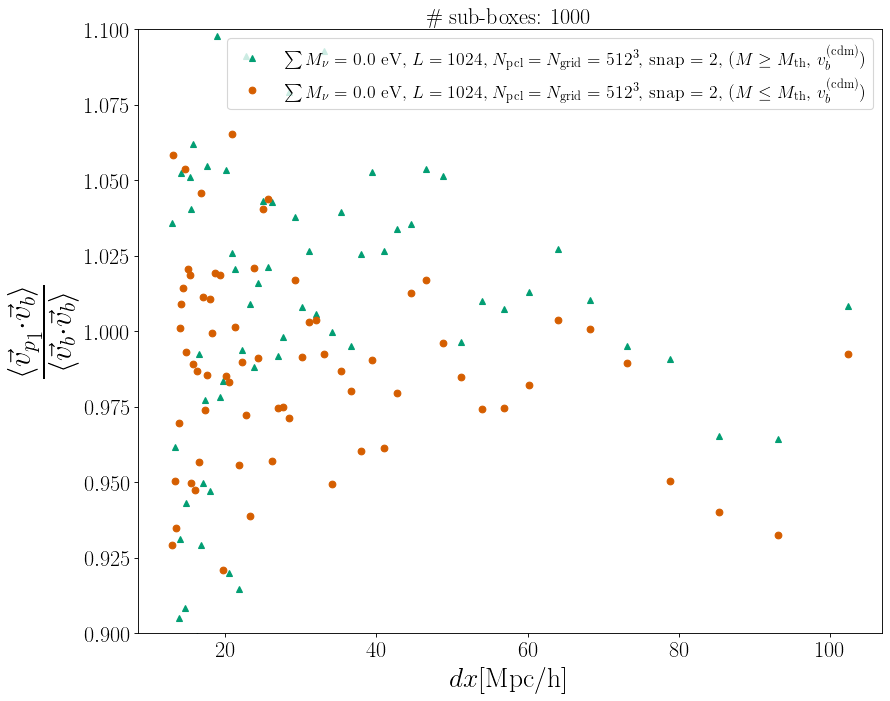

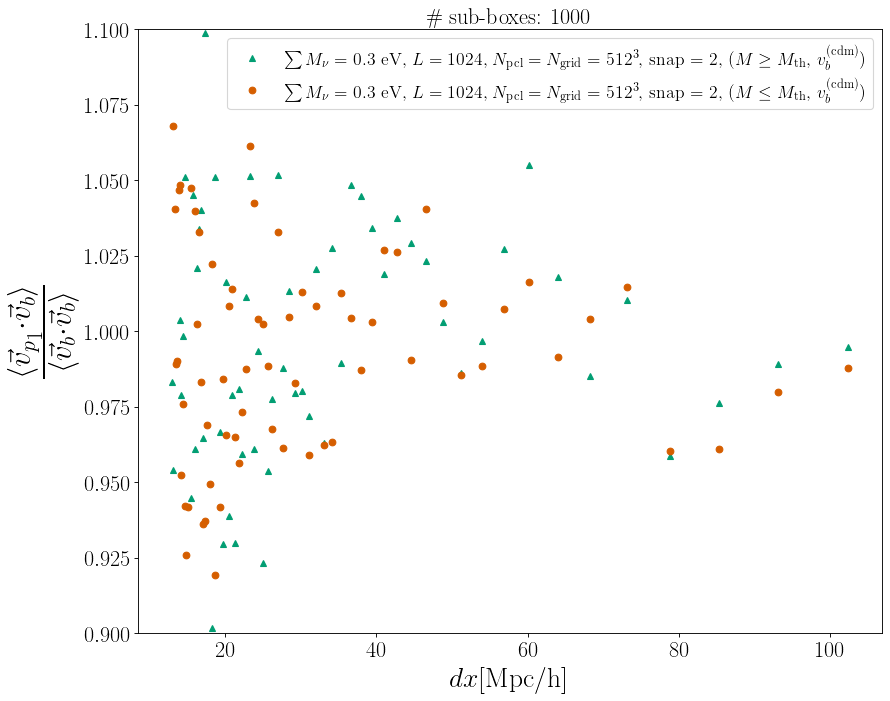

In [94]:
set_points2 = ["^","o","o","*","s","o","*"]
number_samples= 1000;

#########
c=14
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
#########

l=0
str_p1 = r", ($M \ge M_{\rm th}$, $v_b^{(\rm cdm)}$)"
str_p2 = r", ($M \le M_{\rm th}$, $v_b^{(\rm cdm)}$)"

for name in [sims_all[0],sims_all[2]]:
    figure(figsize=(12, 10), dpi=80)
    #############  
    ### conditions: set on the number of samples choses
    #############  
    data_alpha = data_all[name]['halo']
    con1 = (data_alpha['number_samples'] == number_samples) #(data_alpha['number_samples'] == number_samples)
    x_p1 = data_alpha[con1]['dx']
    alpha_p1 = data_alpha[con1]['alpha_p1']
    std_alpha_p1 = data_alpha[con1]['std_alpha_p1']
    
    data_alpha = data_all[name]['cdm']
    con1 = (data_alpha['number_samples'] == number_samples)
    x_p1 = data_alpha[con1]['dx']
    alpha_p1 = data_alpha[con1]['alpha_p1']
    std_alpha_p1 = data_alpha[con1]['std_alpha_p1']
    plt.plot(x_p1, alpha_p1, set_points2[l],color=Colors[l+2], label=parse_name(name)+str_p1)
    x_p2 = data_alpha[con1]['dx']
    alpha_p2 = data_alpha[con1]['alpha_p2']
    plt.plot(x_p2, alpha_p2, set_points2[l+1], color=Colors[l+3], label=parse_name(name)+str_p2)
    
    
    plt.title(" \# sub-boxes: "+ str(number_samples), fontsize=20)
    plt.rcParams['xtick.labelsize']=20
    plt.rcParams['ytick.labelsize']=20
    plt.xlabel("$dx$[Mpc/h]",fontsize=25)
    plt.ylabel(r"$\frac{\langle \vec v_{p_1} \cdot \vec v_{b}  \rangle}{\langle \vec v_{b} \cdot \vec v_{b}  \rangle}$",fontsize=40)
    plt.legend(fontsize=16)
    # plt.xscale('log')
    plt.ylim(0.9,1.1)


In [84]:
name

'0.3ev_L_1024_N_512_snap_2'

In [85]:
parse_name(name)

'$L = 1024$, $N_{\\rm pcl} = N_{ \\rm grid} = 512^3$, snap = 2'

# Comparing the simulations for the LCDM (convergence test)

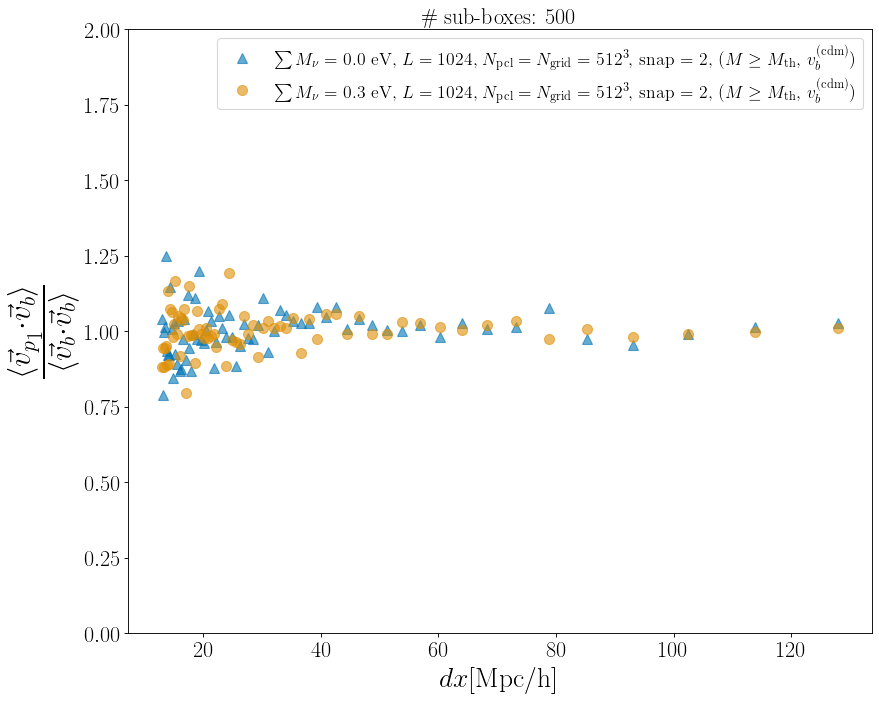

In [95]:
set_points2 = ["^","o","o","*","s","o","*"]
number_samples= 500;

#########
c=14
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
#########

l=0
str_p1 = r", ($M \ge M_{\rm th}$, $v_b^{(\rm cdm)}$)"
str_p2 = r", ($M \le M_{\rm th}$, $v_b^{(\rm cdm)}$)"
figure(figsize=(12, 10), dpi=80)
for name in [sims_all[0],sims_all[2]]:
    # 
    #############  
    ### conditions: set on the number of samples choses
    #############  
    data_alpha = data_all[name]['halo']
    con1 = (data_alpha['number_samples'] == number_samples) #(data_alpha['number_samples'] == number_samples)
    x_p1 = data_alpha[con1]['dx']
    alpha_p1 = data_alpha[con1]['alpha_p1']
    std_alpha_p1 = data_alpha[con1]['std_alpha_p1']
    
    data_alpha = data_all[name]['cdm']
    con1 = (data_alpha['number_samples'] == number_samples)
    x_p1 = data_alpha[con1]['dx']
    alpha_p1 = data_alpha[con1]['alpha_p1']
    std_alpha_p1 = data_alpha[con1]['std_alpha_p1']
    plt.plot(x_p1, alpha_p1, set_points2[l],color=Colors[l], markersize=9, alpha=0.6, label=parse_name(name)+str_p1)
    x_p2 = data_alpha[con1]['dx']
    alpha_p2 = data_alpha[con1]['alpha_p2']
    # plt.plot(x_p2, alpha_p2, set_points2[l], color=Colors[l+4], markersize= 10, alpha=0.7, label=parse_name(name)+str_p2)
    
    
    plt.title(" \# sub-boxes: "+ str(number_samples), fontsize=20)
    plt.rcParams['xtick.labelsize']=20
    plt.rcParams['ytick.labelsize']=20
    plt.xlabel("$dx$[Mpc/h]",fontsize=25)
    plt.ylabel(r"$\frac{\langle \vec v_{p_1} \cdot \vec v_{b}  \rangle}{\langle \vec v_{b} \cdot \vec v_{b}  \rangle}$",fontsize=40)
    plt.legend(fontsize=16)
    # plt.xscale('log')
    plt.ylim(0,2)
    l=l+1


#  The number of analyzed samples for a fixed simulation

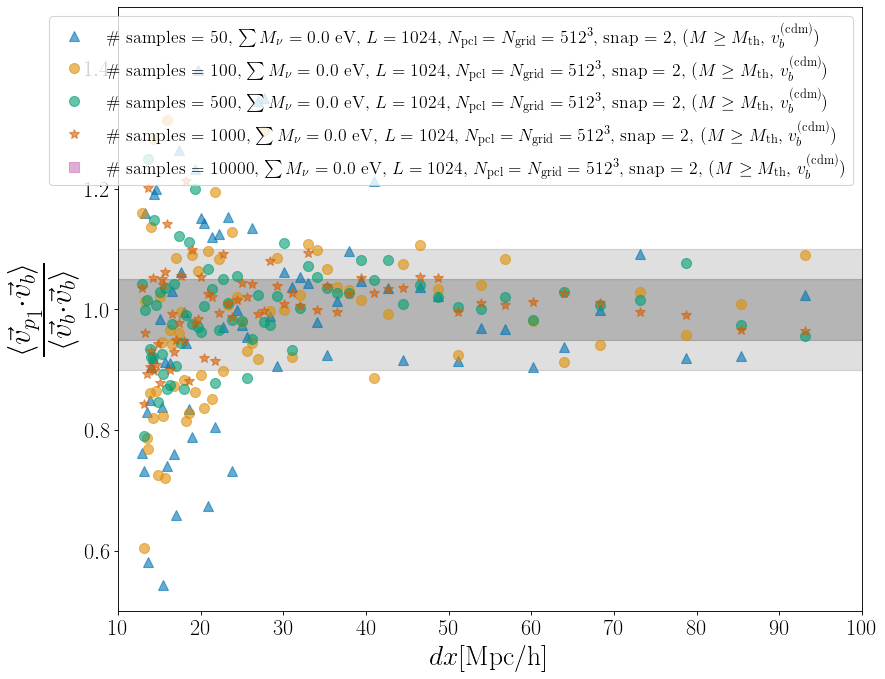

In [96]:
set_points2 = ["^","o","o","*","s","o","*"]


#########
c=14
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
#########

l=0
str_p1 = r", ($M \ge M_{\rm th}$, $v_b^{(\rm cdm)}$)"
str_p2 = r", ($M \le M_{\rm th}$, $v_b^{(\rm cdm)}$)"

x_val = np.arange(0,500,1)
figure(figsize=(12, 10), dpi=80)
for name in [sims_all[0]]:
    for number_samples in [50, 100, 500,1000,10000]:
    # 
    #############  
    ### conditions: set on the number of samples choses
    #############  
        data_alpha = data_all[name]['halo']
        con1 = (data_alpha['number_samples'] == number_samples) #(data_alpha['number_samples'] == number_samples)
        x_p1 = data_alpha[con1]['dx']
        alpha_p1 = data_alpha[con1]['alpha_p1']
        std_alpha_p1 = data_alpha[con1]['std_alpha_p1']

        data_alpha = data_all[name]['cdm']
        con1 = (data_alpha['number_samples'] == number_samples)
        x_p1 = data_alpha[con1]['dx']
        alpha_p1 = data_alpha[con1]['alpha_p1']
        std_alpha_p1 = data_alpha[con1]['std_alpha_p1']
        plt.plot(x_p1, alpha_p1, set_points2[l],color=Colors[l], markersize=9, alpha=0.6, label="\# samples = "+str(number_samples)+", "+parse_name(name)+str_p1)
        x_p2 = data_alpha[con1]['dx']
        alpha_p2 = data_alpha[con1]['alpha_p2']
        # plt.plot(x_p2, alpha_p2, set_points2[l], color=Colors[l+4], markersize= 10, alpha=0.7, label=parse_name(name)+str_p2)
        plt.fill_between(x_val, (1-0.1), (1+0.1), color="gray", alpha=0.05)
        plt.fill_between(x_val, (1-0.05), (1+0.05), color="gray", alpha=0.1)

        # plt.title(" \# sub-boxes: "+ str(number_samples), fontsize=20)
        plt.rcParams['xtick.labelsize']=20
        plt.rcParams['ytick.labelsize']=20
        plt.xlabel("$dx$[Mpc/h]",fontsize=25)
        plt.ylabel(r"$\frac{\langle \vec v_{p_1} \cdot \vec v_{b}  \rangle}{\langle \vec v_{b} \cdot \vec v_{b}  \rangle}$",fontsize=40)
        plt.legend(fontsize=16)
        plt.xlim(10,100)
        plt.ylim(1-0.5,1+0.5)
        l=l+1


# Larger simulation

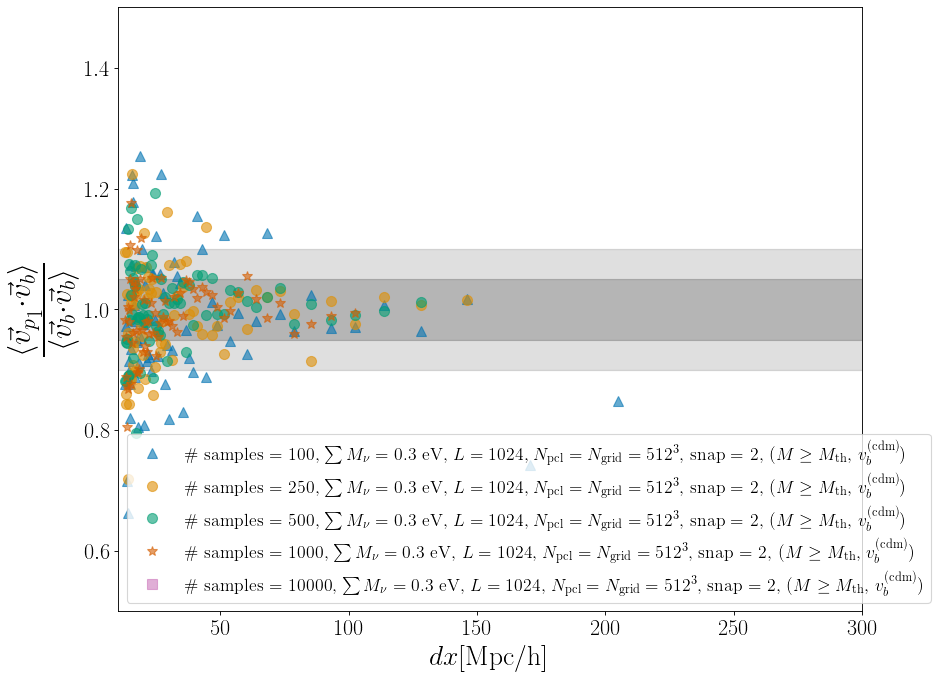

In [97]:
set_points2 = ["^","o","o","*","s","o","*"]


#########
c=14
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
#########

l=0
str_p1 = r", ($M \ge M_{\rm th}$, $v_b^{(\rm cdm)}$)"
str_p2 = r", ($M \le M_{\rm th}$, $v_b^{(\rm cdm)}$)"

x_val = np.arange(0,500,1)
figure(figsize=(12, 10), dpi=80)
for name in [sims_all[2]]:
    for number_samples in [100, 250, 500,1000,10000]:
    # 
    #############  
    ### conditions: set on the number of samples choses
    #############  
        data_alpha = data_all[name]['halo']
        con1 = (data_alpha['number_samples'] == number_samples) #(data_alpha['number_samples'] == number_samples)
        x_p1 = data_alpha[con1]['dx']
        alpha_p1 = data_alpha[con1]['alpha_p1']
        std_alpha_p1 = data_alpha[con1]['std_alpha_p1']

        data_alpha = data_all[name]['cdm']
        con1 = (data_alpha['number_samples'] == number_samples)
        x_p1 = data_alpha[con1]['dx']
        alpha_p1 = data_alpha[con1]['alpha_p1']
        std_alpha_p1 = data_alpha[con1]['std_alpha_p1']
        plt.plot(x_p1, alpha_p1, set_points2[l],color=Colors[l], markersize=9, alpha=0.6, label="\# samples = "+str(number_samples)+", "+parse_name(name)+str_p1)
        x_p2 = data_alpha[con1]['dx']
        alpha_p2 = data_alpha[con1]['alpha_p2']
        # plt.plot(x_p2, alpha_p2, set_points2[l], color=Colors[l+4], markersize= 10, alpha=0.7, label=parse_name(name)+str_p2)
        plt.fill_between(x_val, (1-0.1), (1+0.1), color="gray", alpha=0.05)
        plt.fill_between(x_val, (1-0.05), (1+0.05), color="gray", alpha=0.1)

        # plt.title(" \# sub-boxes: "+ str(number_samples), fontsize=20)
        plt.rcParams['xtick.labelsize']=20
        plt.rcParams['ytick.labelsize']=20
        plt.xlabel("$dx$[Mpc/h]",fontsize=25)
        plt.ylabel(r"$\frac{\langle \vec v_{p_1} \cdot \vec v_{b}  \rangle}{\langle \vec v_{b} \cdot \vec v_{b}  \rangle}$",fontsize=40)
        plt.legend(fontsize=16)
        plt.xlim(10,300)
        plt.ylim(1-0.5,1+0.5)
        l=l+1


## $\alpha$

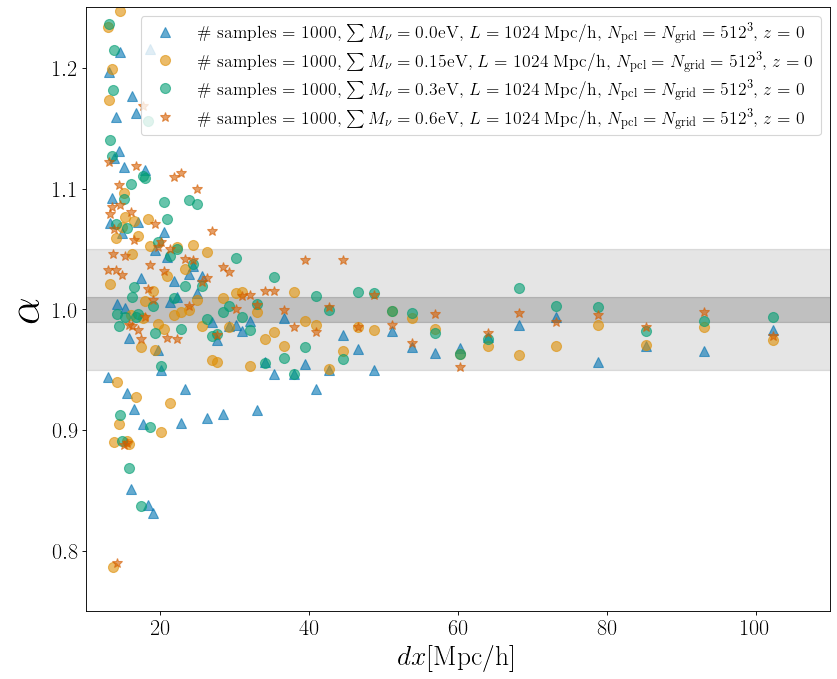

In [124]:
set_points2 = ["^","o","o","*","s","o","*"]


#########
c=14
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
#########

l=0
str_p1 = r", ($M \ge M_{\rm th}$, $v_b^{(\rm cdm)}$)"
str_p2 = r", ($M \le M_{\rm th}$, $v_b^{(\rm cdm)}$)"

x_val = np.arange(0,500,1)
figure(figsize=(12, 10), dpi=80)
for name in [sims_all[0], sims_all[1], sims_all[2], sims_all[3]]:
    for number_samples in [1000]:
    # 
    #############  
    ### conditions: set on the number of samples choses
    #############  
        data_alpha = data_all[name]['halo']
        con1 = (data_alpha['number_samples'] == number_samples) #(data_alpha['number_samples'] == number_samples)
        x_p1 = data_alpha[con1]['dx']
        alpha_p1 = data_alpha[con1]['alpha_p1']
        std_alpha_p1 = data_alpha[con1]['std_alpha_p1']
        alpha_p2 = data_alpha[con1]['alpha_p2']

        # data_alpha = data_all[name]['cdm']
        # con1 = (data_alpha['number_samples'] == number_samples)
        # x_p1 = data_alpha[con1]['dx']
        # alpha_p2 = data_alpha[con1]['alpha_p1']
        # std_alpha_p1 = data_alpha[con1]['std_alpha_p1']
        
        plt.plot(x_p1, alpha_p2/alpha_p1, set_points2[l],color=Colors[l], markersize=9, alpha=0.6, label="\# samples = "+str(number_samples)+", "+parse_name(name))#+str_p1)
        x_p2 = data_alpha[con1]['dx']
        alpha_p2 = data_alpha[con1]['alpha_p2']
        # plt.plot(x_p2, alpha_p2, set_points2[l], color=Colors[l+4], markersize= 10, alpha=0.7, label=parse_name(name)+str_p2)
        plt.fill_between(x_val, (1-0.05), (1+0.05), color="gray", alpha=0.05)
        plt.fill_between(x_val, (1-0.01), (1+0.01), color="gray", alpha=0.1)

        # plt.title(" \# sub-boxes: "+ str(number_samples), fontsize=20)
        plt.rcParams['xtick.labelsize']=20
        plt.rcParams['ytick.labelsize']=20
        plt.xlabel("$dx$[Mpc/h]",fontsize=25)
        plt.ylabel(r"$\alpha$",fontsize=40)
        plt.legend(fontsize=16)
        plt.xlim(10,110)
        plt.ylim(1-0.25,1+0.25)
        l=l+1


In [80]:
sims_all[0]

'0.0ev_L_1024_N_512_snap_2'

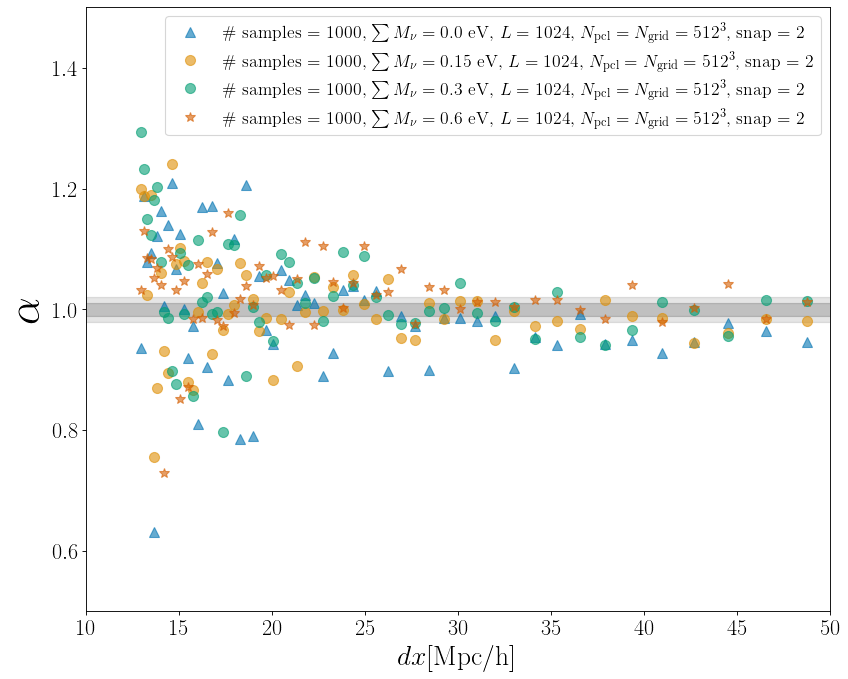

In [104]:
set_points2 = ["^","o","o","*","s","o","*"]


#########
c=14
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
#########

l=0
str_p1 = r", ($M \ge M_{\rm th}$, $v_b^{(\rm cdm)}$)"
str_p2 = r", ($M \le M_{\rm th}$, $v_b^{(\rm cdm)}$)"

x_val = np.arange(0,500,1)
figure(figsize=(12, 10), dpi=80)
for name in [sims_all[0], sims_all[1], sims_all[2], sims_all[3]]:
    for number_samples in [1000]:
    # 
    #############  
    ### conditions: set on the number of samples choses
    #############  
        data_alpha = data_all[name]['halo']
        con1 = (data_alpha['number_samples'] == number_samples) #(data_alpha['number_samples'] == number_samples)
        x_p1 = data_alpha[con1]['dx']
        alpha_p1 = data_alpha[con1]['alpha_p1']
        std_alpha_p1 = data_alpha[con1]['std_alpha_p1']
        alpha_p2 = data_alpha[con1]['alpha_p2']

        # data_alpha = data_all[name]['cdm']
        # con1 = (data_alpha['number_samples'] == number_samples)
        # x_p1 = data_alpha[con1]['dx']
        # alpha_p2 = data_alpha[con1]['alpha_p1']
        # std_alpha_p1 = data_alpha[con1]['std_alpha_p1']
        
        plt.plot(x_p1, 1.-(alpha_p1-alpha_p2), set_points2[l],color=Colors[l], markersize=9, alpha=0.6, label="\# samples = "+str(number_samples)+", "+parse_name(name))#+str_p1)
        x_p2 = data_alpha[con1]['dx']
        alpha_p2 = data_alpha[con1]['alpha_p2']
        # plt.plot(x_p2, alpha_p2, set_points2[l], color=Colors[l+4], markersize= 10, alpha=0.7, label=parse_name(name)+str_p2)
        plt.fill_between(x_val, (1-0.02), (1+0.02), color="gray", alpha=0.05)
        plt.fill_between(x_val, (1-0.01), (1+0.01), color="gray", alpha=0.1)

        # plt.title(" \# sub-boxes: "+ str(number_samples), fontsize=20)
        plt.rcParams['xtick.labelsize']=20
        plt.rcParams['ytick.labelsize']=20
        plt.xlabel("$dx$[Mpc/h]",fontsize=25)
        plt.ylabel(r"$\alpha$",fontsize=40)
        plt.legend(fontsize=16)
        plt.xlim(10,50)
        plt.ylim(1-0.5,1+0.5)
        l=l+1


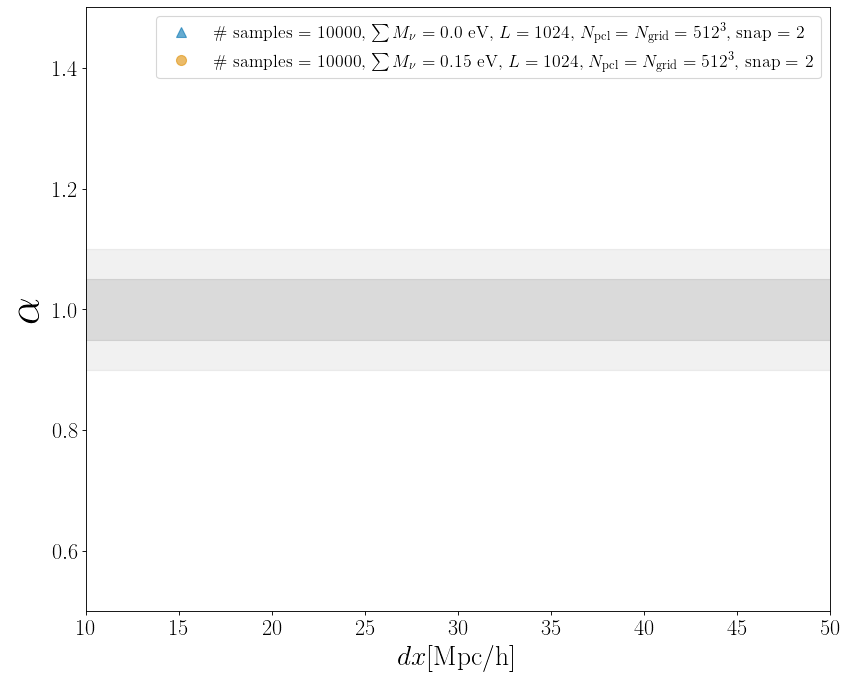

In [101]:
# set_points2 = ["^","o","o","*","s","o","*"]


# #########
# c=14
# plt.rc('text', usetex=True)
# font = {'family' : 'normal',
#         'weight' : 'bold',
#         'size'   : c}
# matplotlib.rc('font', **font)
# #########

# l=0
# str_p1 = r", ($M \ge M_{\rm th}$, $v_b^{(\rm cdm)}$)"
# str_p2 = r", ($M \le M_{\rm th}$, $v_b^{(\rm cdm)}$)"

# x_val = np.arange(0,500,1)
# figure(figsize=(12, 10), dpi=80)
# for name in [sims_all[0], sims_all[1]]:
#     for number_samples in [10000]:
#     # 
#     #############  
#     ### conditions: set on the number of samples choses
#     #############  
#         data_alpha = data_all[name]['halo']
#         con1 = (data_alpha['number_samples'] == number_samples) #(data_alpha['number_samples'] == number_samples)
#         x_p1 = data_alpha[con1]['dx']
#         alpha_p1 = data_alpha[con1]['alpha_p1']
#         std_alpha_p1 = data_alpha[con1]['std_alpha_p1']
#         alpha_p2 = data_alpha[con1]['alpha_p2']

#         # data_alpha = data_all[name]['cdm']
#         # con1 = (data_alpha['number_samples'] == number_samples)
#         # x_p1 = data_alpha[con1]['dx']
#         # alpha_p2 = data_alpha[con1]['alpha_p1']
#         # std_alpha_p1 = data_alpha[con1]['std_alpha_p1']
        
#         plt.plot(x_p1, 1.-(alpha_p1-alpha_p2), set_points2[l],color=Colors[l], markersize=9, alpha=0.6, label="\# samples = "+str(number_samples)+", "+parse_name(name))#+str_p1)
#         x_p2 = data_alpha[con1]['dx']
#         alpha_p2 = data_alpha[con1]['alpha_p2']
#         # plt.plot(x_p2, alpha_p2, set_points2[l], color=Colors[l+4], markersize= 10, alpha=0.7, label=parse_name(name)+str_p2)
#         plt.fill_between(x_val, (1-0.1), (1+0.1), color="gray", alpha=0.05)
#         plt.fill_between(x_val, (1-0.05), (1+0.05), color="gray", alpha=0.1)

#         # plt.title(" \# sub-boxes: "+ str(number_samples), fontsize=20)
#         plt.rcParams['xtick.labelsize']=20
#         plt.rcParams['ytick.labelsize']=20
#         plt.xlabel("$dx$[Mpc/h]",fontsize=25)
#         plt.ylabel(r"$\alpha$",fontsize=40)
#         plt.legend(fontsize=16)
#         plt.xlim(10,50)
#         plt.ylim(1-0.5,1+0.5)
#         l=l+1


# Diving the two for p1 and p2 populations

['lcdm', 'L', '1200', 'N', '512', 'snap', '2']
['Mn', '0d3', 'L', '1200', 'N', '512', 'snap', '2']
['Mn', '0d6', 'L', '1200', 'N', '512', 'snap', '2']


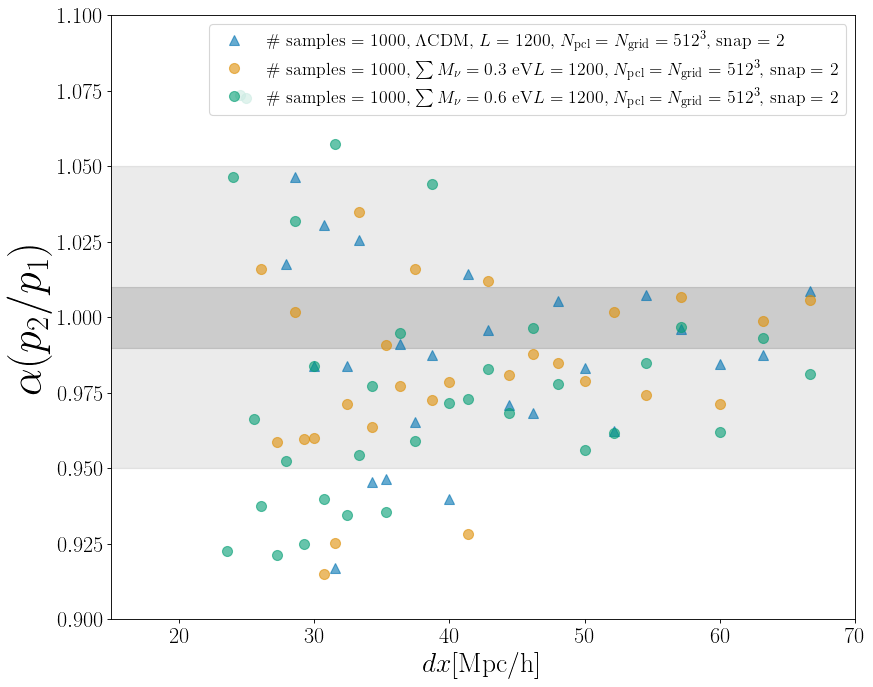

In [179]:
set_points2 = ["^","o","o","*","s","o","*"]


#########
c=14
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
#########

l=0
str_p1 = r", ($M \ge M_{\rm th}$, $v_b^{(\rm cdm)}$)"
str_p2 = r", ($M \le M_{\rm th}$, $v_b^{(\rm cdm)}$)"

x_val = np.arange(0,500,1)
figure(figsize=(12, 10), dpi=80)
for name in [sims_all[2],sims_all[3], sims_all[4]]:
    for number_samples in [1000]:
    # 
    #############  
    ### conditions: set on the number of samples choses
    #############  
        data_alpha = data_all[name]['halo']
        con1 = (data_alpha['number_samples'] == number_samples) #(data_alpha['number_samples'] == number_samples)
        x_p1 = data_alpha[con1]['dx']
        alpha_p1 = data_alpha[con1]['alpha_p1']
        std_alpha_p1 = data_alpha[con1]['std_alpha_p1']
        alpha_p2 = data_alpha[con1]['alpha_p2']

        # data_alpha = data_all[name]['cdm']
        # con1 = (data_alpha['number_samples'] == number_samples)
        # x_p1 = data_alpha[con1]['dx']
        # alpha_p2 = data_alpha[con1]['alpha_p1']
        # std_alpha_p1 = data_alpha[con1]['std_alpha_p1']
        
        plt.plot(x_p1, alpha_p1/alpha_p2, set_points2[l],color=Colors[l], markersize=9, alpha=0.6, label="\# samples = "+str(number_samples)+", "+parse_name(name))#+str_p1)
        x_p2 = data_alpha[con1]['dx']
        alpha_p2 = data_alpha[con1]['alpha_p2']
        # plt.plot(x_p2, alpha_p2, set_points2[l], color=Colors[l+4], markersize= 10, alpha=0.7, label=parse_name(name)+str_p2)
        plt.fill_between(x_val, (1-0.05), (1+0.05), color="gray", alpha=0.05)
        plt.fill_between(x_val, (1-0.01), (1+0.01), color="gray", alpha=0.1)

        # plt.title(" \# sub-boxes: "+ str(number_samples), fontsize=20)
        plt.rcParams['xtick.labelsize']=20
        plt.rcParams['ytick.labelsize']=20
        plt.xlabel("$dx$[Mpc/h]",fontsize=25)
        plt.ylabel(r"$\alpha(p_2/p_1)$",fontsize=40)
        plt.legend(fontsize=16)
        plt.xlim(15,70)
        plt.ylim(1-0.1,1+0.1)
        l=l+1


In [ ]:
1024^3

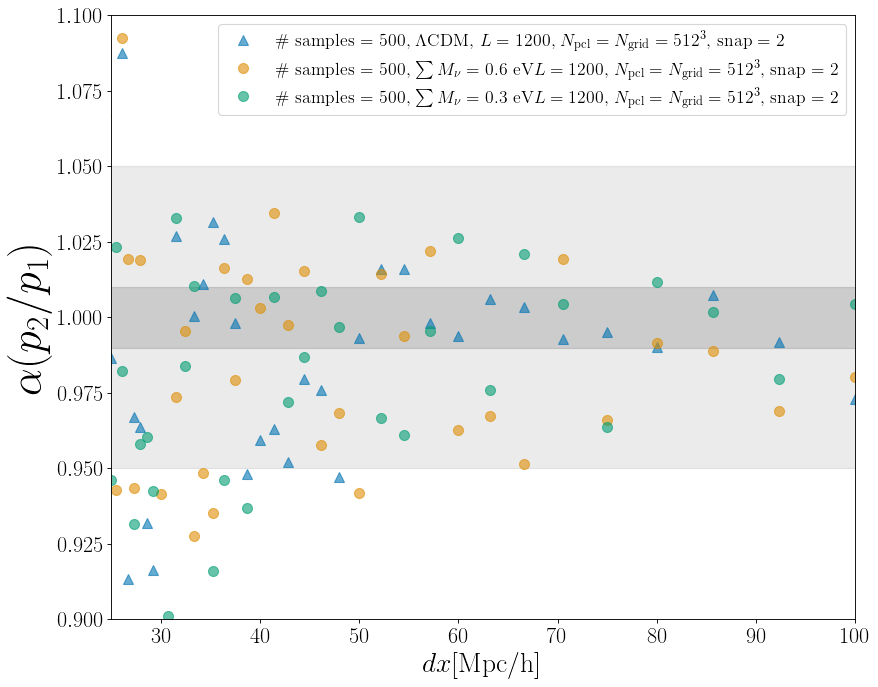

In [48]:
set_points2 = ["^","o","o","*","s","o","*"]


#########
c=14
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
#########

l=0
str_p1 = r", ($M \ge M_{\rm th}$, $v_b^{(\rm cdm)}$)"
str_p2 = r", ($M \le M_{\rm th}$, $v_b^{(\rm cdm)}$)"

x_val = np.arange(0,500,1)
figure(figsize=(12, 10), dpi=80)
for name in [sims_all[2], sims_all[4],sims_all[3]]:
    for number_samples in [500]:
    # 
    #############  
    ### conditions: set on the number of samples choses
    #############  
        data_alpha = data_all[name]['halo']
        con1 = (data_alpha['number_samples'] == number_samples) #(data_alpha['number_samples'] == number_samples)
        x_p1 = data_alpha[con1]['dx']
        alpha_p1 = data_alpha[con1]['alpha_p1']
        std_alpha_p1 = data_alpha[con1]['std_alpha_p1']
        alpha_p2 = data_alpha[con1]['alpha_p2']

        # data_alpha = data_all[name]['cdm']
        # con1 = (data_alpha['number_samples'] == number_samples)
        # x_p1 = data_alpha[con1]['dx']
        # alpha_p2 = data_alpha[con1]['alpha_p1']
        # std_alpha_p1 = data_alpha[con1]['std_alpha_p1']
        
        plt.plot(x_p1, 1+alpha_p1-alpha_p2, set_points2[l],color=Colors[l], markersize=9, alpha=0.6, label="\# samples = "+str(number_samples)+", "+parse_name(name))#+str_p1)
        x_p2 = data_alpha[con1]['dx']
        alpha_p2 = data_alpha[con1]['alpha_p2']
        # plt.plot(x_p2, alpha_p2, set_points2[l], color=Colors[l+4], markersize= 10, alpha=0.7, label=parse_name(name)+str_p2)
        plt.fill_between(x_val, (1-0.05), (1+0.05), color="gray", alpha=0.05)
        plt.fill_between(x_val, (1-0.01), (1+0.01), color="gray", alpha=0.1)

        # plt.title(" \# sub-boxes: "+ str(number_samples), fontsize=20)
        plt.rcParams['xtick.labelsize']=20
        plt.rcParams['ytick.labelsize']=20
        plt.xlabel("$dx$[Mpc/h]",fontsize=25)
        plt.ylabel(r"$\alpha(p_2/p_1)$",fontsize=40)
        plt.legend(fontsize=16)
        plt.xlim(25,100)
        plt.ylim(1-0.1,1+0.1)
        l=l+1


In [ ]:
# set_points2 = ["^","s","o","*","s","o","*"]
# number_samples= 25;



# l=0
# for name in sims_all[2:3]:
#     figure(figsize=(12, 10), dpi=80)
#     #############  
#     ### conditions: set on the number of samples choses
#     #############  
#     data_alpha = data_all[name]['halo']
#     con1 = (data_alpha['number_samples'] == data_alpha['number_samples']) #(data_alpha['number_samples'] == number_samples)
#     x_p1 = data_alpha[con1]['dx']
#     alpha_p1 = data_alpha[con1]['alpha_p1']
#     std_alpha_p1 = data_alpha[con1]['std_alpha_p1']
#     # plt.plot(x_p1, alpha_p1, set_points2[l],color=Colors[l], label=name+", halo_p1, bulk (halos)")
    
#     x_p2 = data_alpha[con1]['dx']
#     alpha_p2 = data_alpha[con1]['alpha_p2']
#     plt.plot(x_p2, (alpha_p2-alpha_p1), set_points[l], label=name)
#     # l=l+1

#     plt.title("number of samples: "+ str(number_samples), fontsize=20)
#     plt.rcParams['xtick.labelsize']=16
#     plt.rcParams['ytick.labelsize']=16
#     plt.xlabel("dx[Mpc/h]",fontsize=25)
#     plt.ylabel(r"$ \alpha_{p2}- \alpha_{p1}$",fontsize=25)
#     plt.legend(fontsize=16)
    
#     plt.axhline(y=0, color='red', linewidth=2)

#     # plt.xscale('log')
#     plt.xlim(10,100) 
#     plt.ylim(-0.25,0.25) 



## $\alpha_{p_2}/\alpha_{p_1} -1$ Figure

In [108]:
set_points2 = ["^","s","o","*","s","o","*"]
number_samples= 25;


l=0
for name in sims_all:
    figure(figsize=(10, 8), dpi=80)
    #############  
    ### conditions: set on the number of samples choses
    #############  
    data_alpha = data_all [name] 
    con1 = (data_alpha['number_samples'] == number_samples)
    x_p1 = data_alpha[con1]['dx']
    alpha_p1 = data_alpha[con1]['alpha_p1']
    std_alpha_p1 = data_alpha[con1]['std_alpha_p1']    
    x_p2 = data_alpha[con1]['dx']
    alpha_p2 = data_alpha[con1]['alpha_p2']

    plt.plot(x_p2, (alpha_p2/alpha_p1)-1, set_points[l], label=name)
    plt.axhline(y=0, color='red', linewidth=2)

    plt.title("number of samples: "+ str(number_samples), fontsize=20)
    plt.rcParams['xtick.labelsize']=16
    plt.rcParams['ytick.labelsize']=16
    plt.xlabel("dx[Mpc/h]",fontsize=25)
    plt.ylabel(r"$\alpha_{p1}/\alpha_{p2}$-1",fontsize=25)
    plt.legend(fontsize=16)
    # plt.xscale('log')
    plt.xlim(10,100)   



TypeError: unsupported operand type(s) for /: 'collections.defaultdict' and 'collections.defaultdict'

<Figure size 800x640 with 0 Axes>

## Figure Comparison

## Simulation size effect

In [ ]:
set_points = ["^","s","o","*","s","o","*"]
number_samples= 1000;


l=0
figure(figsize=(10, 8), dpi=80)
for name in ['Mn_0d6_L_512_N_256_snap_3','lcdm_L_512_N_256_snap_3']:
    
    #############  
    ### conditions: set on the number of samples choses
    #############  
    data_alpha = data_all [name] 
    con1 = (data_alpha['number_samples'] == number_samples)
    x_p1 = data_alpha[con1]['dx']
    alpha_p1 = data_alpha[con1]['alpha_p1']
    std_alpha_p1 = data_alpha[con1]['std_alpha_p1']    
    x_p2 = data_alpha[con1]['dx']
    alpha_p2 = data_alpha[con1]['alpha_p2']

    plt.plot(x_p2, (alpha_p2/alpha_p1)-1, set_points[l], label=name)
    plt.axhline(y=0, color='red', linewidth=2)

    plt.title("number of samples: "+ str(number_samples), fontsize=20)
    plt.rcParams['xtick.labelsize']=16
    plt.rcParams['ytick.labelsize']=16
    plt.xlabel("dx[Mpc/h]",fontsize=25)
    plt.ylabel(r"$\alpha_{p1}/\alpha_{p2}$-1",fontsize=25)
    plt.legend(fontsize=16)
    # plt.xscale('log')
    plt.xlim(10,100)   
    l=l+1



In [ ]:
set_points2 = ["^","s","o","*","s","o","*"]
number_samples= 500;


l=0
figure(figsize=(10, 8), dpi=80)
for name in ['lcdm_L_1200_N_512_snap_2','lcdm_L_512_N_256_snap_3']:
    
    #############  
    ### conditions: set on the number of samples choses
    #############  
    data_alpha = data_all [name] 
    con1 = (data_alpha['number_samples'] == number_samples)
    x_p1 = data_alpha[con1]['dx']
    alpha_p1 = data_alpha[con1]['alpha_p1']
    std_alpha_p1 = data_alpha[con1]['std_alpha_p1']    
    x_p2 = data_alpha[con1]['dx']
    alpha_p2 = data_alpha[con1]['alpha_p2']

    plt.plot(x_p2, (alpha_p2/alpha_p1)-1, set_points[l], label=name)
    plt.axhline(y=0, color='red', linewidth=2)

    plt.title("number of samples: "+ str(number_samples), fontsize=20)
    plt.rcParams['xtick.labelsize']=16
    plt.rcParams['ytick.labelsize']=16
    plt.xlabel("dx[Mpc/h]",fontsize=25)
    plt.ylabel(r"$\alpha_{p1}/\alpha_{p2}$-1",fontsize=25)
    plt.legend(fontsize=16)
    # plt.xscale('log')
    plt.xlim(10,100)   
    l=l+1



In [ ]:
set_points = ["^","s","o","*","s","o","*","."]


l=0
for name in ['lcdm_L_1200_N_512_snap_2','lcdm_L_512_N_256_snap_3']:
    figure(figsize=(10, 8), dpi=80)
    l=0
    for number_samples in [25, 50, 100, 250, 500, 1000]:
    #############  
    ### conditions: set on the number of samples choses
    #############  
        data_alpha = data_all[name] 
        con1 = (data_alpha['number_samples'] == number_samples)
        x_p1 = data_alpha[con1]['dx']
        alpha_p1 = data_alpha[con1]['alpha_p1']
        std_alpha_p1 = data_alpha[con1]['std_alpha_p1']    
        x_p2 = data_alpha[con1]['dx']
        alpha_p2 = data_alpha[con1]['alpha_p2']

        plt.plot(x_p2, (alpha_p2/alpha_p1)-1, set_points[l] ,color = Colors[l], label=str(number_samples))
        plt.axhline(y=0, color='red', linewidth=2)

        plt.title("sim: "+ name, fontsize=20)
        plt.rcParams['xtick.labelsize']=16
        plt.rcParams['ytick.labelsize']=16
        plt.xlabel("dx[Mpc/h]",fontsize=25)
        plt.ylabel(r"$\alpha_{p1}/\alpha_{p2}$-1",fontsize=25)
        plt.legend(fontsize=16)
        plt.ylim(-0.2,0.2)
        plt.xlim(10,100)   
        l=l+1



In [ ]:
sims_all

In [ ]:
set_points2 = ["^","s","o","*","s","o","*"]
number_samples= 250;


l=0
figure(figsize=(10, 8), dpi=80)
for name in ['Mn_0d6_L_1200_N_512_snap_2','Mn_0d6_L_512_N_256_snap_3']:
    
    #############  
    ### conditions: set on the number of samples choses
    #############  
    data_alpha = data_all [name] 
    con1 = (data_alpha['number_samples'] == number_samples)
    x_p1 = data_alpha[con1]['dx']
    alpha_p1 = data_alpha[con1]['alpha_p1']
    std_alpha_p1 = data_alpha[con1]['std_alpha_p1']    
    x_p2 = data_alpha[con1]['dx']
    alpha_p2 = data_alpha[con1]['alpha_p2']

    plt.plot(x_p2, (alpha_p2/alpha_p1)-1, set_points[l], label=name)
    plt.axhline(y=0, color='red', linewidth=2)

    plt.title("number of samples: "+ str(number_samples), fontsize=20)
    plt.rcParams['xtick.labelsize']=16
    plt.rcParams['ytick.labelsize']=16
    plt.xlabel("dx[Mpc/h]",fontsize=25)
    plt.ylabel(r"$\alpha_{p1}/\alpha_{p2}$-1",fontsize=25)
    plt.legend(fontsize=16)
    # plt.xscale('log')
    plt.xlim(10,100)   
    l=l+1



In [ ]:
set_points = ["^","s","o","*","s","o","*"]
number_samples= 500;


l=0
figure(figsize=(10, 8), dpi=80)
for name in ['lcdm_L_1200_N_512_snap_2','Mn_0d6_L_1200_N_512_snap_2','Mn_0d3_L_1200_N_512_snap_2']:
    
    #############  
    ### conditions: set on the number of samples choses
    #############  
    data_alpha = data_all [name] 
    con1 = (data_alpha['number_samples'] == number_samples)
    x_p1 = data_alpha[con1]['dx']
    alpha_p1 = data_alpha[con1]['alpha_p1']
    std_alpha_p1 = data_alpha[con1]['std_alpha_p1']    
    x_p2 = data_alpha[con1]['dx']
    alpha_p2 = data_alpha[con1]['alpha_p2']

    plt.plot(x_p2, (alpha_p2/alpha_p1)-1, set_points[l], label=name)
    plt.axhline(y=0, color='red', linewidth=2)

    plt.title("number of samples: "+ str(number_samples), fontsize=20)
    plt.rcParams['xtick.labelsize']=16
    plt.rcParams['ytick.labelsize']=16
    plt.xlabel("dx[Mpc/h]",fontsize=25)
    plt.ylabel(r"$\alpha_{p1}/\alpha_{p2}$-1",fontsize=25)
    plt.legend(fontsize=16)
    # plt.xscale('log')
    plt.xlim(10,100)   
    l=l+1



In [ ]:
set_points = ["^","s","o","*","s","o","*"]
number_samples= 1000;


l=0
figure(figsize=(10, 8), dpi=80)
for name in ['Mn_0d6_L_512_N_256_snap_3','lcdm_L_512_N_256_snap_3']:
    
    #############  
    ### conditions: set on the number of samples choses
    #############  
    data_alpha = data_all [name] 
    con1 = (data_alpha['number_samples'] == number_samples)
    x_p1 = data_alpha[con1]['dx']
    alpha_p1 = data_alpha[con1]['alpha_p1']
    std_alpha_p1 = data_alpha[con1]['std_alpha_p1']    
    x_p2 = data_alpha[con1]['dx']
    alpha_p2 = data_alpha[con1]['alpha_p2']

    plt.plot(x_p2, (alpha_p2/alpha_p1)-1, set_points[l], label=name)
    plt.axhline(y=0, color='red', linewidth=2)

    plt.title("number of samples: "+ str(number_samples), fontsize=20)
    plt.rcParams['xtick.labelsize']=16
    plt.rcParams['ytick.labelsize']=16
    plt.xlabel("dx[Mpc/h]",fontsize=25)
    plt.ylabel(r"$\alpha_{p1}/\alpha_{p2}$-1",fontsize=25)
    plt.legend(fontsize=16)
    # plt.xscale('log')
    plt.xlim(10,100)   
    l=l+1



# $\alpha$ histogram for a given $N_{grid}$

In [ ]:
# from matplotlib.pyplot import figure
# figure(figsize=(8, 6), dpi=80)

# for ngrid in [2,3]:
#     boxsize=1024.;
#     mass_limit = 1.e14;
#     verbose="n"
#     alpha_all_h1=[]
#     alpha_all_h2=[]
#     for num in [3]: # the snapshot number start from high redshift
#         for sim in ['lcdm', 'Mn_0d6']:
#             for i in range(ngrid):
#                 for j in range(ngrid):
#                     for k in range(ngrid):
#                         sub_box_index=[i,j,k];
#                         alpha_all_h1.append(data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos<=mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]])
#                         alpha_all_h2.append(data['alpha_avg']['mass_limit='+str(mass_limit)]['sim='+sim]['halos>mass_cut']['ngrid='+str(ngrid)][sub_box_index[0]][sub_box_index[1]][sub_box_index[2]])

#             counts, bins = np.histogram(alpha_all_h2, bins=5, range=None, normed=None, weights=None, density=None)
#             plt.stairs(counts, bins, alpha=1,hatch=':', label="sim:"+sim+", ngrid:"+str(ngrid)+", halo1")
#             plt.legend()
#             ######
#             # counts, bins = np.histogram(alpha_all_h2, bins=5, range=None, normed=None, weights=None, density=None)
#             # plt.stairs(counts, bins, alpha=0.1, hatch='.',fill=True, label="sim:"+sim+", ngrid:"+str(ngrid)+", halo2")
#             plt.legend()
# # plt.